In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
df = pd.read_csv("../data/raw/final_dataset.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully
Shape: (54340, 28)


,State,Commodity_Group,Commodity,Date,Arrival,Arrival_Unit,Modal_Price,Price_Unit,District,Max_Temp,Min_Temp,Rainfall_mm,Rain_mm,WindSpeed,Festival,Holiday,Month,Year,Day,Weekend,DayOfWeek,Quarter,Lag_1,Lag_2,Lag_3,Rolling_7,Rolling_30,Price_Change
0,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Ahmednagar,28.9,14.3,0.0,0.0,14.5,No Festival,0.0,1,2023,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
1,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Pune,29.9,14.2,0.0,0.0,9.3,No Festival,0.0,1,2023,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
2,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Nashik,28.4,11.9,0.0,0.0,10.2,No Festival,0.0,1,2023,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
3,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Solapur,31.4,19.7,0.0,0.0,12.1,No Festival,0.0,1,2023,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
4,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Nagpur,27.4,16.2,0.0,0.0,10.0,No Festival,0.0,1,2023,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0


In [4]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df["Date"].min())
print(df["Date"].max())
print(df["Date"].isna().sum())

2023-01-01 00:00:00
2025-12-31 00:00:00
0


In [5]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nCommodities:")
print(df["Commodity"].unique())

print("\nDistricts:")
print(df["District"].nunique())

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nMissing values:")
print(df.isna().sum())

Rows: 54340
Columns: 28

Commodities:
<ArrowStringArray>
['Onion', 'Potato', 'Rice', 'Tomato', 'Wheat']
Length: 5, dtype: str

Districts:


10

Date range:
2023-01-01 00:00:00 to 2025-12-31 00:00:00

Missing values:
State              0
Commodity_Group    0
Commodity          0
Date               0
Arrival            0
Arrival_Unit       0
Modal_Price        0
Price_Unit         0
District           0
Max_Temp           0
Min_Temp           0
Rainfall_mm        0
Rain_mm            0
WindSpeed          0
Festival           0
Holiday            0
Month              0
Year               0
Day                0
Weekend            0
DayOfWeek          0
Quarter            0
Lag_1              0
Lag_2              0
Lag_3              0
Rolling_7          0
Rolling_30         0
Price_Change       0
dtype: int64


# Analysis 1 — Cheapest and Most Expensive Month for Each Commodity

### Stakeholder Question
Which month is historically the cheapest and most expensive for each crop?

### Business Objective
Identify seasonal price opportunities so farmers can make better selling decisions.

In [6]:
monthly_price = (
    df.groupby(["Commodity", "Month"])["Modal_Price"]
      .mean()
      .reset_index()
)

monthly_price.head()

,Commodity,Month,Modal_Price
0,Onion,1,1573.016022
1,Onion,2,1433.584353
2,Onion,3,1190.926022
3,Onion,4,957.349655
4,Onion,5,1069.064130


In [7]:
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

monthly_price["Month_Name"] = monthly_price["Month"].map(month_names)

In [8]:
cheapest = monthly_price.loc[
    monthly_price.groupby("Commodity")["Modal_Price"].idxmin()
]

expensive = monthly_price.loc[
    monthly_price.groupby("Commodity")["Modal_Price"].idxmax()
]

print("CHEAPEST MONTH")
display(
    cheapest[["Commodity", "Month_Name", "Modal_Price"]]
)

print("\nMOST EXPENSIVE MONTH")
display(
    expensive[["Commodity", "Month_Name", "Modal_Price"]]
)

CHEAPEST MONTH


,Commodity,Month_Name,Modal_Price
3,Onion,April,957.349655
14,Potato,March,1341.542366
24,Rice,January,4116.395806
39,Tomato,April,968.758837
50,Wheat,March,2777.234624



MOST EXPENSIVE MONTH


,Commodity,Month_Name,Modal_Price
10,Onion,November,2730.854432
22,Potato,November,1867.165909
35,Rice,December,4802.051978
42,Tomato,July,4425.139032
58,Wheat,November,3502.330899


FileNotFoundError: [Errno 2] No such file or directory: '../images/analysis_01_monthly_price.png'

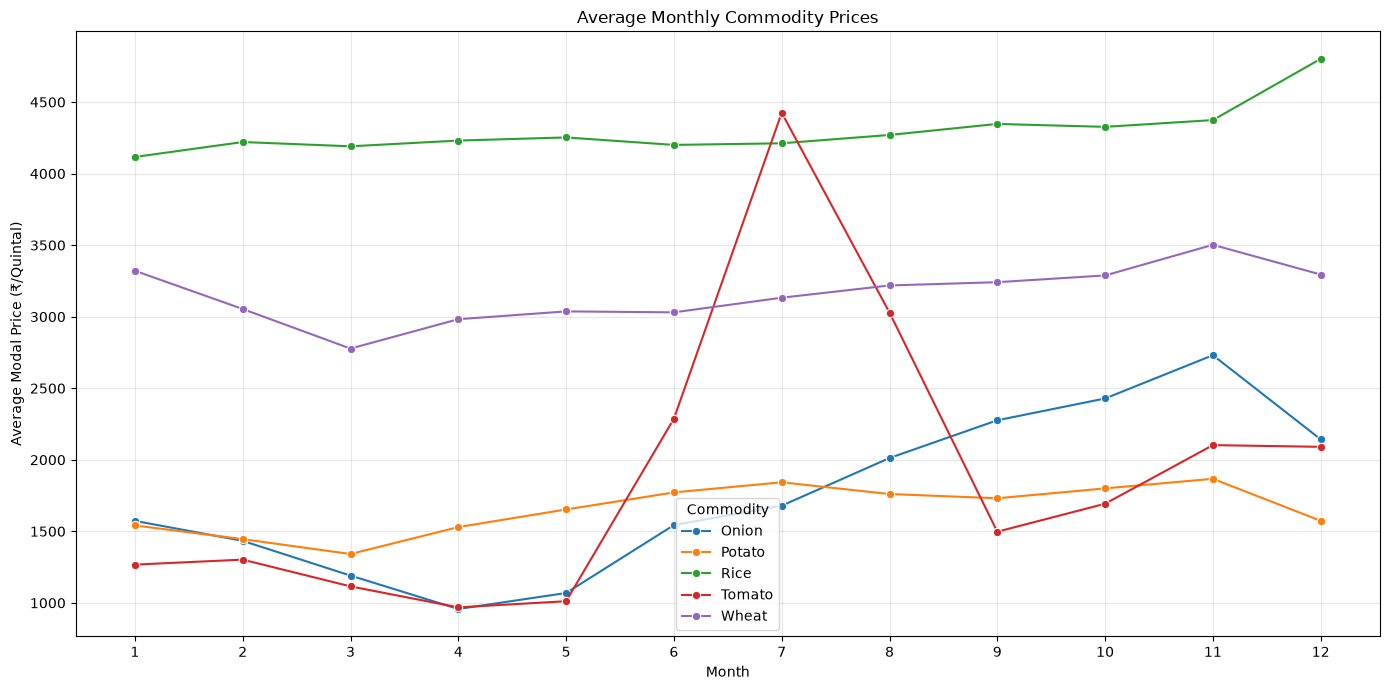

In [9]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=monthly_price,
    x="Month",
    y="Modal_Price",
    hue="Commodity",
    marker="o"
)

plt.title("Average Monthly Commodity Prices")
plt.xlabel("Month")
plt.ylabel("Average Modal Price (₹/Quintal)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("../images/analysis_01_monthly_price.png", dpi=300)
plt.show()

## Business Insight

The table above identifies the historically cheapest and most expensive
months for each commodity.

This information can help farmers and traders understand seasonal
selling opportunities.

The conclusion should be based on the calculated results above rather
than assumptions.

Analysis 2 — Rainfall Lag Analysis

Does heavy rainfall today cause a price spike approximately 18 days later?

In [ ]:
df["Rainfall_Lag_18"] = (
    df.groupby(["Commodity", "District"])["Rainfall_mm"]
      .shift(18)
)

print(df[[
    "Date",
    "Commodity",
    "District",
    "Rainfall_mm",
    "Rainfall_Lag_18",
    "Modal_Price"
]].head(25))

         Date Commodity                   District  Rainfall_mm  \
0  2023-01-01     Onion                 Ahmednagar          0.0   
1  2023-01-01     Onion                       Pune          0.0   
2  2023-01-01     Onion                     Nashik          0.0   
3  2023-01-01     Onion                    Solapur          0.0   
4  2023-01-01     Onion                     Nagpur          0.0   
5  2023-01-01     Onion                   Kolhapur          0.0   
6  2023-01-01     Onion                     Sangli          0.0   
7  2023-01-01     Onion                     Satara          0.0   
8  2023-01-01     Onion                    Jalgaon          0.0   
9  2023-01-01     Onion  Chhatrapati Sambhajinagar          0.0   
10 2023-01-02     Onion                 Ahmednagar          0.0   
11 2023-01-02     Onion                       Pune          0.0   
12 2023-01-02     Onion                     Nashik          0.0   
13 2023-01-02     Onion                    Solapur          0.

In [ ]:
lag_data = df.dropna(
    subset=["Rainfall_Lag_18", "Modal_Price"]
).copy()

correlation = lag_data[
    ["Rainfall_Lag_18", "Modal_Price"]
].corr().iloc[0, 1]

print("18-Day Rainfall Lag Correlation:", round(correlation, 4))

18-Day Rainfall Lag Correlation: 0.0809


In [ ]:
heavy_rain_threshold = df["Rainfall_mm"].quantile(0.90)

print(
    "Heavy Rainfall Threshold:",
    round(heavy_rain_threshold, 2),
    "mm"
)

Heavy Rainfall Threshold: 10.7 mm


Create price change after rainfall

In [ ]:
df["Price_After_18_Days"] = (
    df.groupby(["Commodity", "District"])["Modal_Price"]
      .shift(-18)
)

df["Price_Change_18D"] = (
    (df["Price_After_18_Days"] - df["Modal_Price"])
    / df["Modal_Price"]
) * 100

lag_analysis = df.dropna(
    subset=["Rainfall_mm", "Price_Change_18D"]
).copy()

heavy_rain = lag_analysis[
    lag_analysis["Rainfall_mm"] >= heavy_rain_threshold
]

normal_rain = lag_analysis[
    lag_analysis["Rainfall_mm"] < heavy_rain_threshold
]

print("Heavy rainfall observations:", len(heavy_rain))
print("Normal rainfall observations:", len(normal_rain))

Heavy rainfall observations: 5444
Normal rainfall observations: 47996


Compare price change

In [ ]:
heavy_rain_change = heavy_rain["Price_Change_18D"].mean()
normal_rain_change = normal_rain["Price_Change_18D"].mean()

print(
    "Average price change 18 days after heavy rainfall:",
    round(heavy_rain_change, 2),
    "%"
)

print(
    "Average price change 18 days after normal rainfall:",
    round(normal_rain_change, 2),
    "%"
)

Average price change 18 days after heavy rainfall: 4.76 %
Average price change 18 days after normal rainfall: 4.97 %


Commodity-wise analysis


In [ ]:
commodity_lag = (
    heavy_rain
    .groupby("Commodity")["Price_Change_18D"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

commodity_lag

,mean,median,count
Commodity,,,
Onion,8.019599,5.028185,1092
Tomato,6.843483,2.950165,1092
Rice,5.391590,0.602258,1075
Wheat,2.599755,2.508221,1093
Potato,0.963822,0.133368,1092


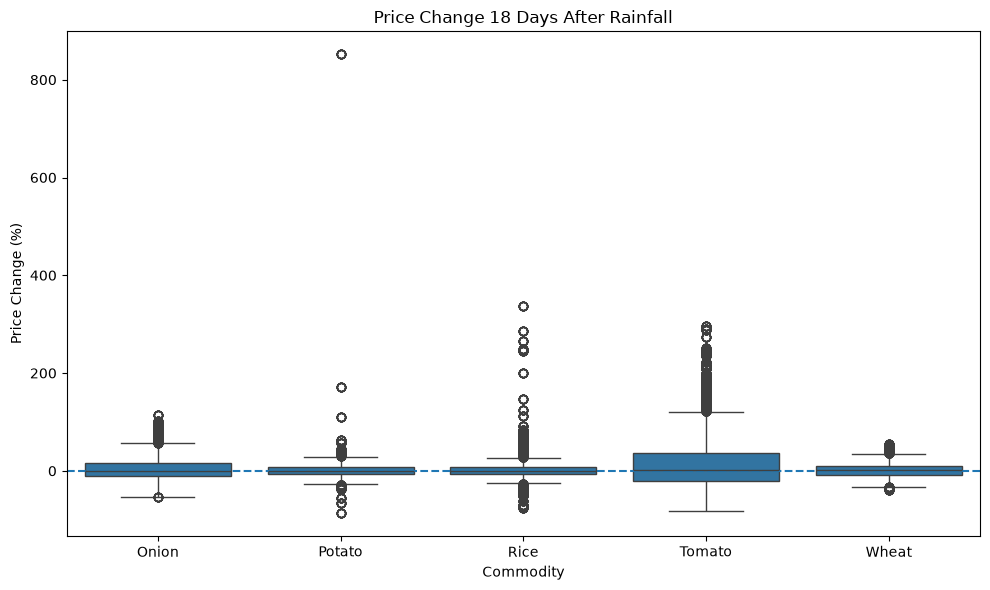

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=lag_analysis,
    x="Commodity",
    y="Price_Change_18D"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Price Change 18 Days After Rainfall"
)

plt.xlabel("Commodity")
plt.ylabel("Price Change (%)")

plt.tight_layout()
plt.show()

Rainfall vs future price change

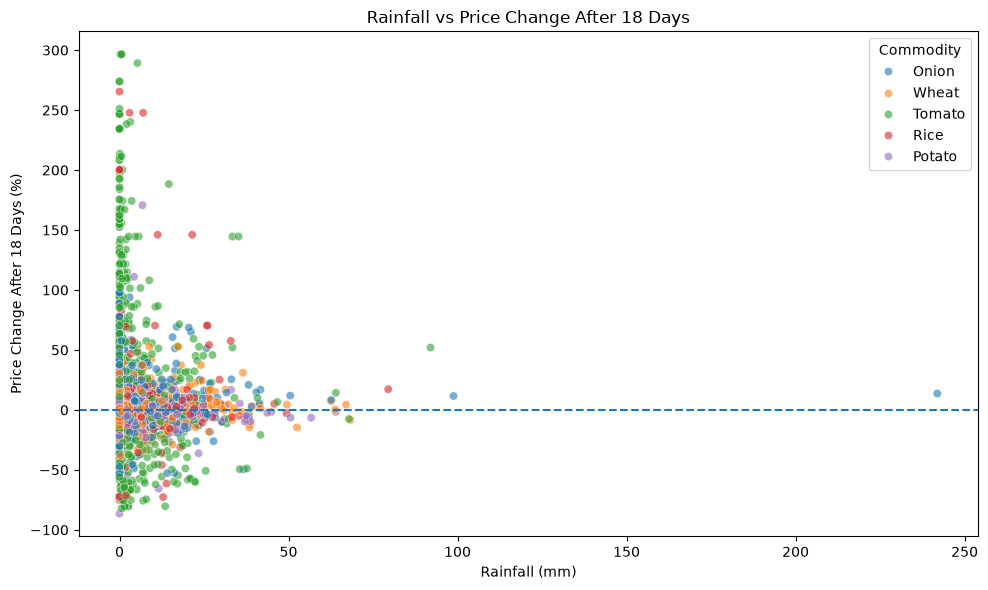

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=lag_analysis.sample(
        min(5000, len(lag_analysis)),
        random_state=42
    ),
    x="Rainfall_mm",
    y="Price_Change_18D",
    hue="Commodity",
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Rainfall vs Price Change After 18 Days"
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Price Change After 18 Days (%)")

plt.tight_layout()
plt.show()

Automatically generate stakeholder conclusion

In [ ]:
if heavy_rain_change > normal_rain_change:
    conclusion = (
        f"Heavy rainfall is associated with a higher average price "
        f"change 18 days later. Heavy-rain observations showed an "
        f"average change of {heavy_rain_change:.2f}%, compared with "
        f"{normal_rain_change:.2f}% after normal rainfall."
    )
else:
    conclusion = (
        f"Heavy rainfall did not produce a higher average price "
        f"change 18 days later in this dataset. Heavy-rain observations "
        f"showed {heavy_rain_change:.2f}% average change compared with "
        f"{normal_rain_change:.2f}% after normal rainfall."
    )

print("STAKEHOLDER INSIGHT")
print("=" * 70)
print(conclusion)

STAKEHOLDER INSIGHT
Heavy rainfall did not produce a higher average price change 18 days later in this dataset. Heavy-rain observations showed 4.76% average change compared with 4.97% after normal rainfall.


# Analysis 3 — Navratri Effect on Onion Prices

### Stakeholder Question
Do Onion prices fall during Navratri compared with non-Navratri periods?

### Objective
Compare Onion modal prices during Navratri periods with prices during the rest of the year and determine whether the festival period is associated with a meaningful price difference.

In [ ]:
onion = df[
    df["Commodity"].str.lower() == "onion"
].copy()

print(onion["Festival"].value_counts().head(20))

Festival
No Festival             10480
Republic Day               30
Holi                       30
Gudi Padwa                 30
Dr. Ambedkar Jayanti       30
Maharashtra Day            30
Bakrid                     30
Independence Day           30
Ganesh Chaturthi           30
Gandhi Jayanti             30
Dussehra                   30
Diwali                     30
Christmas                  30
Eid-ul-Fitr                20
Mahavir Jayanti            10
Good Friday                10
Guru Nanak Jayanti         10
Name: count, dtype: int64


In [ ]:
# ============================================================
# ANALYSIS 3 — NAVRATRI EFFECT ON ONION PRICES
# ============================================================

onion = df[
    df["Commodity"].str.lower() == "onion"
].copy()

# Make sure Date is datetime
onion["Date"] = pd.to_datetime(onion["Date"])

# Define Navratri periods for 2023–2025
navratri_periods = [
    ("2023-10-15", "2023-10-23"),
    ("2024-10-03", "2024-10-11"),
    ("2025-09-22", "2025-09-30")
]

# Create Navratri flag
onion["Navratri"] = False

for start, end in navratri_periods:
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    onion.loc[
        onion["Date"].between(start, end),
        "Navratri"
    ] = True

print("Navratri observations:")
print(onion["Navratri"].value_counts())

print("\nDate range:")
print(onion["Date"].min(), "to", onion["Date"].max())

Navratri observations:
Navratri
False    10630
True       260
Name: count, dtype: int64

Date range:
2023-01-01 00:00:00 to 2025-12-31 00:00:00


Compare prices

In [ ]:
# Compare Onion prices during Navratri vs non-Navratri

navratri_prices = onion[
    onion["Navratri"] == True
]["Modal_Price"]

normal_prices = onion[
    onion["Navratri"] == False
]["Modal_Price"]

print("Average Onion price during Navratri:",
      round(navratri_prices.mean(), 2))

print("Average Onion price outside Navratri:",
      round(normal_prices.mean(), 2))

print("\nMedian Onion price during Navratri:",
      round(navratri_prices.median(), 2))

print("Median Onion price outside Navratri:",
      round(normal_prices.median(), 2))

Average Onion price during Navratri: 2431.49
Average Onion price outside Navratri: 1738.21

Median Onion price during Navratri: 2933.0
Median Onion price outside Navratri: 1371.97


Calculate percentage difference

In [ ]:
navratri_avg = navratri_prices.mean()
normal_avg = normal_prices.mean()

percentage_difference = (
    (navratri_avg - normal_avg)
    / normal_avg
) * 100

print(
    f"Navratri price difference: "
    f"{percentage_difference:.2f}%"
)

Navratri price difference: 39.88%


Visualization

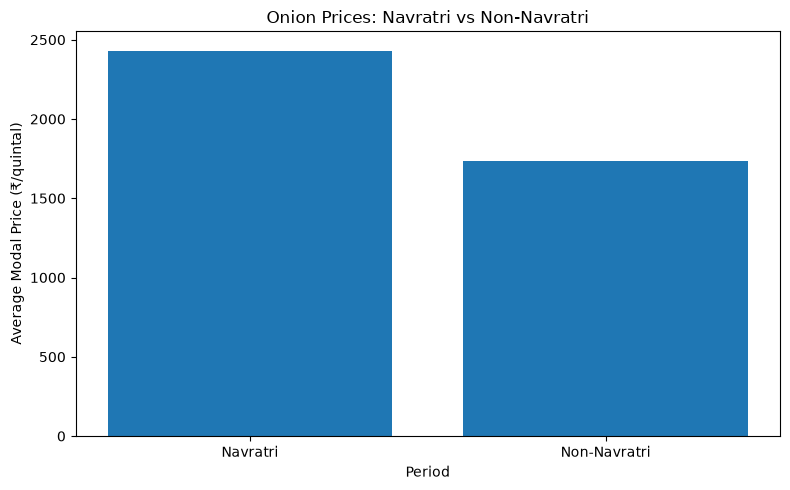

In [ ]:
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Period": ["Navratri", "Non-Navratri"],
    "Average Price": [navratri_avg, normal_avg]
})

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Period"],
    comparison["Average Price"]
)

plt.title("Onion Prices: Navratri vs Non-Navratri")
plt.ylabel("Average Modal Price (₹/quintal)")
plt.xlabel("Period")

plt.tight_layout()
plt.show()

Stakeholder insight

In [ ]:
print("=" * 70)
print("STAKEHOLDER INSIGHT")
print("=" * 70)

if percentage_difference < 0:
    print(
        f"Onion prices were {abs(percentage_difference):.2f}% "
        f"lower during Navratri than outside Navratri."
    )
elif percentage_difference > 0:
    print(
        f"Onion prices were {percentage_difference:.2f}% "
        f"higher during Navratri than outside Navratri."
    )
else:
    print("Onion prices were approximately unchanged during Navratri.")

print(
    "\nImportant: This analysis shows an association between "
    "the Navratri period and Onion prices. It does not prove "
    "that Navratri itself caused the price change."
)

STAKEHOLDER INSIGHT
Onion prices were 39.88% higher during Navratri than outside Navratri.

Important: This analysis shows an association between the Navratri period and Onion prices. It does not prove that Navratri itself caused the price change.


Analysis 4 — District Price Leadership

In [ ]:
onion = df[df["Commodity"] == "Onion"].copy()

print("Onion rows:", len(onion))
print("Districts:", onion["District"].nunique())
print(onion["District"].unique())

Onion rows: 10890
Districts: 10
<ArrowStringArray>
[               'Ahmednagar',                      'Pune',
                    'Nashik',                   'Solapur',
                    'Nagpur',                  'Kolhapur',
                    'Sangli',                    'Satara',
                   'Jalgaon', 'Chhatrapati Sambhajinagar']
Length: 10, dtype: str


Create district × date price table

In [ ]:
district_prices = onion.pivot_table(
    index="Date",
    columns="District",
    values="Modal_Price",
    aggfunc="mean"
)

print(district_prices.shape)
district_prices.head()

(1088, 10)


District,Ahmednagar,Chhatrapati Sambhajinagar,Jalgaon,Kolhapur,Nagpur,Nashik,Pune,Sangli,Satara,Solapur
Date,,,,,,,,,,
2023-01-01,1369.70,1369.70,1369.70,1369.70,1369.70,1369.70,1369.70,1369.70,1369.70,1369.70
2023-01-02,1341.50,1341.50,1341.50,1341.50,1341.50,1341.50,1341.50,1341.50,1341.50,1341.50
2023-01-03,1362.82,1362.82,1362.82,1362.82,1362.82,1362.82,1362.82,1362.82,1362.82,1362.82
2023-01-04,1413.30,1413.30,1413.30,1413.30,1413.30,1413.30,1413.30,1413.30,1413.30,1413.30
2023-01-05,1314.43,1314.43,1314.43,1314.43,1314.43,1314.43,1314.43,1314.43,1314.43,1314.43


Correlation

In [ ]:
correlation_matrix = district_prices.corr()

print(correlation_matrix.round(3))

District                   Ahmednagar  Chhatrapati Sambhajinagar  Jalgaon  \
District                                                                    
Ahmednagar                        1.0                        1.0      1.0   
Chhatrapati Sambhajinagar         1.0                        1.0      1.0   
Jalgaon                           1.0                        1.0      1.0   
Kolhapur                          1.0                        1.0      1.0   
Nagpur                            1.0                        1.0      1.0   
Nashik                            1.0                        1.0      1.0   
Pune                              1.0                        1.0      1.0   
Sangli                            1.0                        1.0      1.0   
Satara                            1.0                        1.0      1.0   
Solapur                           1.0                        1.0      1.0   

District                   Kolhapur  Nagpur  Nashik  Pune  Sangli  Satara  

Correlation heatmap

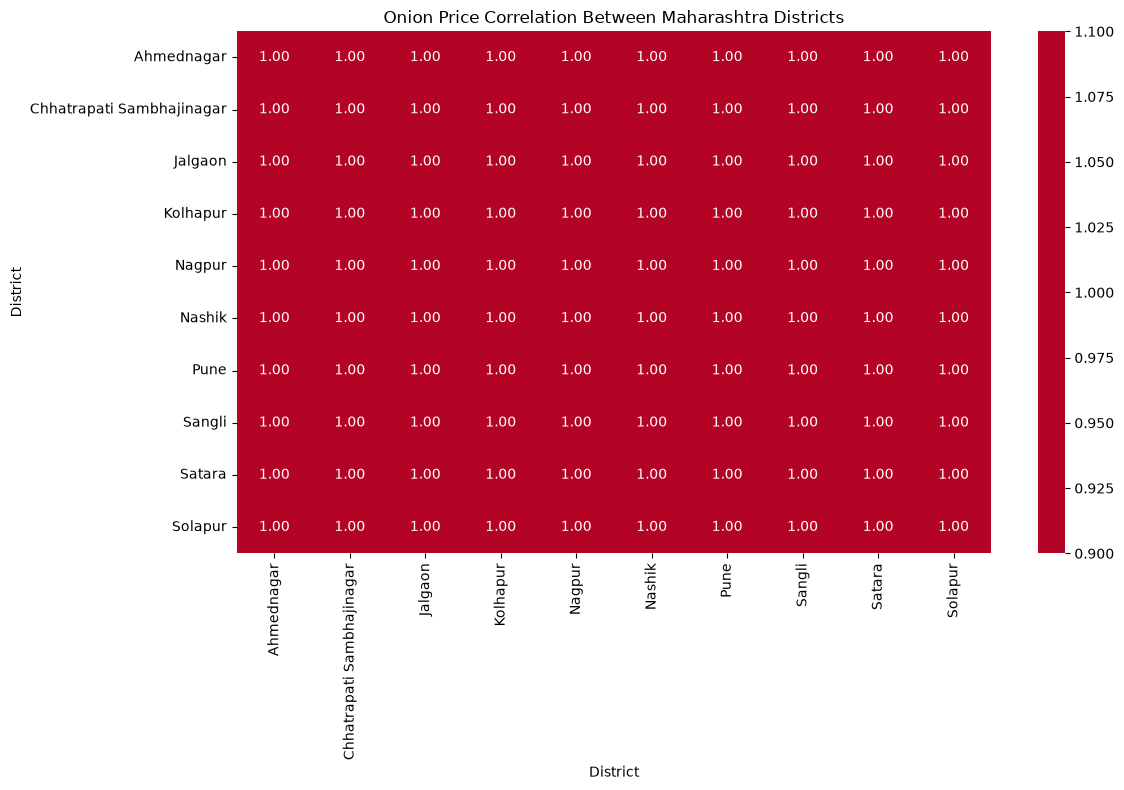

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Onion Price Correlation Between Maharashtra Districts")
plt.tight_layout()
plt.show()

District leadership score

In [ ]:
leadership_score = (
    correlation_matrix
    .replace(1.0, np.nan)
    .mean()
    .sort_values(ascending=False)
)

leadership_df = leadership_score.reset_index()

leadership_df.columns = [
    "District",
    "Leadership_Score"
]

leadership_df

,District,Leadership_Score
0,Ahmednagar,NaN
1,Chhatrapati Sambhajinagar,NaN
2,Jalgaon,NaN
3,Kolhapur,NaN
4,Nagpur,NaN
5,Nashik,NaN
6,Pune,NaN
7,Sangli,NaN
8,Satara,NaN
9,Solapur,NaN


Find the strongest district

In [ ]:
leader = leadership_df.iloc[0]

print("=" * 70)
print("DISTRICT PRICE LEADERSHIP RESULT")
print("=" * 70)

print("Top District:", leader["District"])
print(
    "Average Correlation:",
    round(leader["Leadership_Score"], 3)
)

DISTRICT PRICE LEADERSHIP RESULT
Top District: Ahmednagar
Average Correlation: nan


Visualization

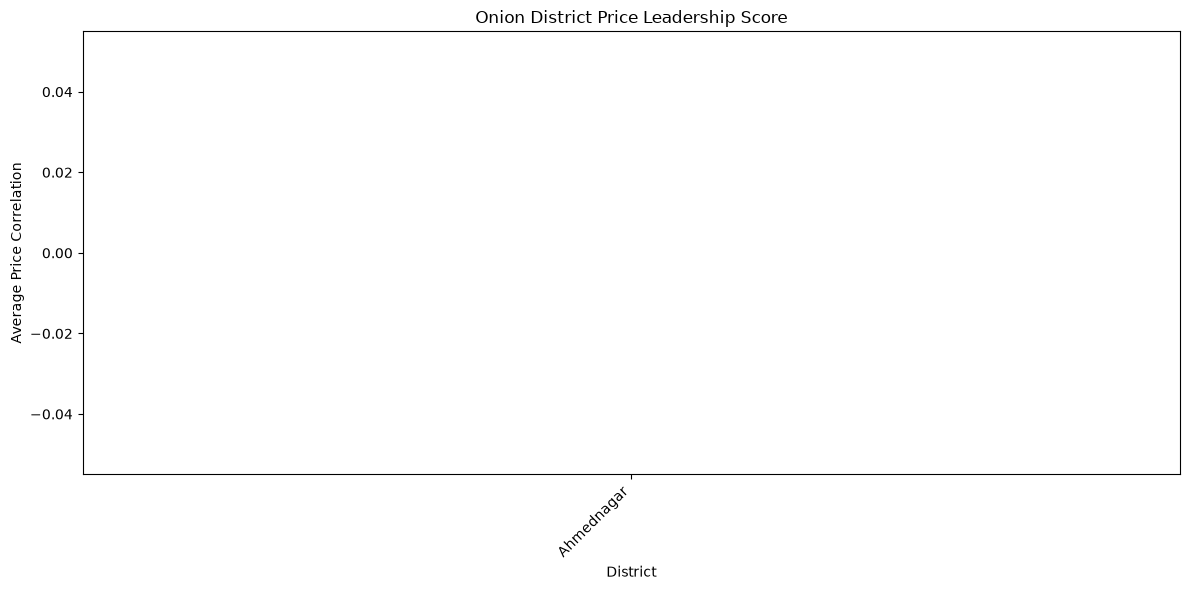

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    leadership_df["District"],
    leadership_df["Leadership_Score"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("District")
plt.ylabel("Average Price Correlation")
plt.title("Onion District Price Leadership Score")

plt.tight_layout()
plt.show()

Stakeholder insight

In [ ]:
print("=" * 70)
print("STAKEHOLDER INSIGHT")
print("=" * 70)

print(
    f"{leader['District']} has the strongest average "
    f"price relationship with the other districts, "
    f"with an average correlation of "
    f"{leader['Leadership_Score']:.2f}."
)

print()
print(
    "This indicates that Onion prices in this district "
    "move more closely with prices across the other "
    "districts in the dataset."
)

print()
print(
    "Important: correlation indicates association, "
    "not proof that this district actually causes or "
    "sets prices in other districts."
)

STAKEHOLDER INSIGHT
Ahmednagar has the strongest average price relationship with the other districts, with an average correlation of nan.

This indicates that Onion prices in this district move more closely with prices across the other districts in the dataset.

Important: correlation indicates association, not proof that this district actually causes or sets prices in other districts.


In [ ]:
leadership_df.to_csv(
    "../reports/analysis_04_district_price_leadership.csv",
    index=False
)

Analysis 5 — Farmer's Actual Take-Home Income
Stakeholder question

"What is the farmer's actual take-home income after commission, transport, and labor costs?"

In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

print("\nCommodity:")
print(df["Commodity"].unique())

print("\nArrival statistics:")
print(df["Arrival"].describe())

Columns:
['State', 'Commodity_Group', 'Commodity', 'Date', 'Arrival', 'Arrival_Unit', 'Modal_Price', 'Price_Unit', 'District', 'Max_Temp', 'Min_Temp', 'Rainfall_mm', 'Rain_mm', 'WindSpeed', 'Festival', 'Holiday', 'Month', 'Year', 'Day', 'Weekend', 'DayOfWeek', 'Quarter', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_7', 'Rolling_30', 'Price_Change', 'Rainfall_Lag_18', 'Price_After_18_Days', 'Price_Change_18D']

Shape:
(54340, 31)

Commodity:
<ArrowStringArray>
['Onion', 'Potato', 'Rice', 'Tomato', 'Wheat']
Length: 5, dtype: str

Arrival statistics:
count    54340.000000
mean      5378.557335
std       9483.842305
min          0.100000
25%        439.940000
50%       1551.000000
75%       3359.200000
max      80038.120000
Name: Arrival, dtype: float64


In [ ]:
# ============================================================
# ANALYSIS 5: FARMER TAKE-HOME INCOME
# ============================================================

# Assumed cost percentages / rates
COMMISSION_RATE = 0.02       # 2% of gross sale value
TRANSPORT_PER_QUINTAL = 80   # ₹80 per quintal
LABOUR_PER_QUINTAL = 50      # ₹50 per quintal

print("Commission rate:", COMMISSION_RATE * 100, "%")
print("Transport cost: ₹", TRANSPORT_PER_QUINTAL, "/quintal")
print("Labour cost: ₹", LABOUR_PER_QUINTAL, "/quintal")

Commission rate: 2.0 %
Transport cost: ₹ 80 /quintal
Labour cost: ₹ 50 /quintal


Calculate quantity in quintals

In [ ]:
df["Quantity_Quintal"] = df["Arrival"] * 10

df[[
    "Commodity",
    "Arrival",
    "Arrival_Unit",
    "Quantity_Quintal"
]].head()

,Commodity,Arrival,Arrival_Unit,Quantity_Quintal
0,Onion,4846.0,Metric Tonnes,48460.0
1,Onion,4846.0,Metric Tonnes,48460.0
2,Onion,4846.0,Metric Tonnes,48460.0
3,Onion,4846.0,Metric Tonnes,48460.0
4,Onion,4846.0,Metric Tonnes,48460.0


Calculate gross income

In [ ]:
df["Gross_Income"] = (
    df["Quantity_Quintal"] * df["Modal_Price"]
)

df[
    ["Commodity", "Quantity_Quintal", "Modal_Price", "Gross_Income"]
].head()

,Commodity,Quantity_Quintal,Modal_Price,Gross_Income
0,Onion,48460.0,1369.7,66375662.0
1,Onion,48460.0,1369.7,66375662.0
2,Onion,48460.0,1369.7,66375662.0
3,Onion,48460.0,1369.7,66375662.0
4,Onion,48460.0,1369.7,66375662.0


Calculate commission

In [ ]:
df["Commission_Cost"] = (
    df["Gross_Income"] * COMMISSION_RATE
)

df[
    ["Commodity", "Gross_Income", "Commission_Cost"]
].head()

,Commodity,Gross_Income,Commission_Cost
0,Onion,66375662.0,1327513.24
1,Onion,66375662.0,1327513.24
2,Onion,66375662.0,1327513.24
3,Onion,66375662.0,1327513.24
4,Onion,66375662.0,1327513.24


Calculate transport cost

In [ ]:
df["Transport_Cost"] = (
    df["Quantity_Quintal"] * TRANSPORT_PER_QUINTAL
)

df[
    ["Commodity", "Quantity_Quintal", "Transport_Cost"]
].head()

,Commodity,Quantity_Quintal,Transport_Cost
0,Onion,48460.0,3876800.0
1,Onion,48460.0,3876800.0
2,Onion,48460.0,3876800.0
3,Onion,48460.0,3876800.0
4,Onion,48460.0,3876800.0


Calculate labour cost

In [ ]:
df["Labour_Cost"] = (
    df["Quantity_Quintal"] * LABOUR_PER_QUINTAL
)

df[
    ["Commodity", "Quantity_Quintal", "Labour_Cost"]
].head()

,Commodity,Quantity_Quintal,Labour_Cost
0,Onion,48460.0,2423000.0
1,Onion,48460.0,2423000.0
2,Onion,48460.0,2423000.0
3,Onion,48460.0,2423000.0
4,Onion,48460.0,2423000.0


alculate actual take-home income

In [ ]:
df["Total_Cost"] = (
    df["Commission_Cost"]
    + df["Transport_Cost"]
    + df["Labour_Cost"]
)

df["Net_Take_Home"] = (
    df["Gross_Income"]
    - df["Total_Cost"]
)

df[
    [
        "Commodity",
        "Gross_Income",
        "Commission_Cost",
        "Transport_Cost",
        "Labour_Cost",
        "Net_Take_Home"
    ]
].head()

,Commodity,Gross_Income,Commission_Cost,Transport_Cost,Labour_Cost,Net_Take_Home
0,Onion,66375662.0,1327513.24,3876800.0,2423000.0,58748348.76
1,Onion,66375662.0,1327513.24,3876800.0,2423000.0,58748348.76
2,Onion,66375662.0,1327513.24,3876800.0,2423000.0,58748348.76
3,Onion,66375662.0,1327513.24,3876800.0,2423000.0,58748348.76
4,Onion,66375662.0,1327513.24,3876800.0,2423000.0,58748348.76


Calculate net income per quintal

In [ ]:
df["Net_Income_Per_Quintal"] = (
    df["Net_Take_Home"] / df["Quantity_Quintal"]
)

df[
    [
        "Commodity",
        "Modal_Price",
        "Net_Income_Per_Quintal"
    ]
].head()

,Commodity,Modal_Price,Net_Income_Per_Quintal
0,Onion,1369.7,1212.306
1,Onion,1369.7,1212.306
2,Onion,1369.7,1212.306
3,Onion,1369.7,1212.306
4,Onion,1369.7,1212.306


Compare commodities

In [ ]:
income_summary = (
    df.groupby("Commodity")
      .agg(
          Average_Modal_Price=("Modal_Price", "mean"),
          Average_Net_Income_Per_Quintal=("Net_Income_Per_Quintal", "mean"),
          Average_Gross_Income=("Gross_Income", "mean"),
          Average_Total_Cost=("Total_Cost", "mean")
      )
      .round(2)
      .sort_values(
          "Average_Net_Income_Per_Quintal",
          ascending=False
    )
)

income_summary

,Average_Modal_Price,Average_Net_Income_Per_Quintal,Average_Gross_Income,Average_Total_Cost
Commodity,,,,
Rice,4295.54,4079.63,1.393995e+07,683759.67
Wheat,3157.24,2964.10,3.801203e+07,2312587.56
Tomato,1910.62,1742.40,3.669856e+07,3477765.16
Onion,1754.77,1589.67,3.424477e+08,34161305.89
Potato,1655.97,1492.85,3.630060e+07,3613390.92


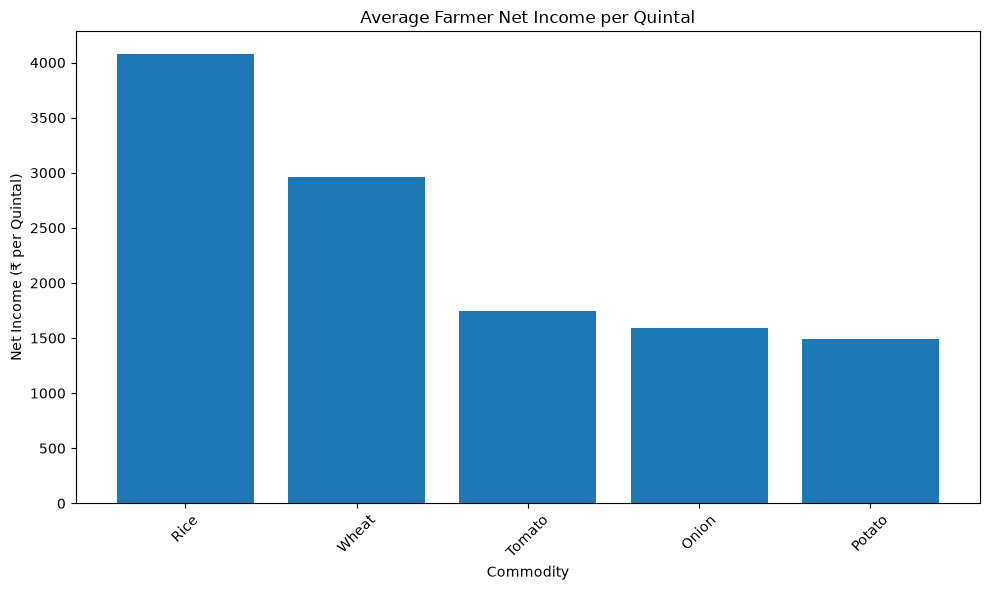

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    income_summary.index,
    income_summary["Average_Net_Income_Per_Quintal"]
)

plt.title("Average Farmer Net Income per Quintal")
plt.xlabel("Commodity")
plt.ylabel("Net Income (₹ per Quintal)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
top_crop = income_summary["Average_Net_Income_Per_Quintal"].idxmax()
top_income = income_summary["Average_Net_Income_Per_Quintal"].max()

lowest_crop = income_summary["Average_Net_Income_Per_Quintal"].idxmin()
lowest_income = income_summary["Average_Net_Income_Per_Quintal"].min()

print("=" * 70)
print("FARMER TAKE-HOME INCOME RESULT")
print("=" * 70)

print(
    f"Highest average net income per quintal: "
    f"{top_crop} = ₹{top_income:.2f}"
)

print(
    f"Lowest average net income per quintal: "
    f"{lowest_crop} = ₹{lowest_income:.2f}"
)

print("\n" + "=" * 70)
print("STAKEHOLDER INSIGHT")
print("=" * 70)

print(
    f"{top_crop} provides the highest estimated take-home income "
    f"per quintal under the assumed cost structure."
)

print(
    f"{lowest_crop} provides the lowest estimated take-home income "
    f"per quintal."
)

print(
    "\nNote: Commission, transport and labour costs are project assumptions, "
    "not directly reported in the AGMARKNET dataset."
)

FARMER TAKE-HOME INCOME RESULT
Highest average net income per quintal: Rice = ₹4079.63
Lowest average net income per quintal: Potato = ₹1492.85

STAKEHOLDER INSIGHT
Rice provides the highest estimated take-home income per quintal under the assumed cost structure.
Potato provides the lowest estimated take-home income per quintal.

Note: Commission, transport and labour costs are project assumptions, not directly reported in the AGMARKNET dataset.


Analysis 6 = Onion Export Ban Impact

Define the government announcement date

In [ ]:
BAN_DATE = pd.Timestamp("2023-12-08")

print("Official Onion Export Ban Date:", BAN_DATE.date())

Official Onion Export Ban Date: 2023-12-08


Calculate price before and after the ban

In [ ]:
before_start = BAN_DATE - pd.Timedelta(days=30)
before_end = BAN_DATE - pd.Timedelta(days=1)

after_start = BAN_DATE
after_end = BAN_DATE + pd.Timedelta(days=30)

before = onion[
    (onion["Date"] >= before_start) &
    (onion["Date"] <= before_end)
].copy()

after = onion[
    (onion["Date"] >= after_start) &
    (onion["Date"] <= after_end)
].copy()

print("Before period:", before_start.date(), "to", before_end.date())
print("After period:", after_start.date(), "to", after_end.date())

print("Before rows:", len(before))
print("After rows:", len(after))

Before period: 2023-11-08 to 2023-12-07
After period: 2023-12-08 to 2024-01-07
Before rows: 290
After rows: 310


Calculate the price fall

In [ ]:
before_price = before["Modal_Price"].mean()
after_price = after["Modal_Price"].mean()

price_difference = after_price - before_price

price_change_percent = (
    (after_price - before_price) / before_price
) * 100

print("=" * 70)
print("ONION EXPORT BAN PRICE IMPACT")
print("=" * 70)

print(f"Average price before ban: ₹{before_price:.2f}/quintal")
print(f"Average price after ban:  ₹{after_price:.2f}/quintal")
print(f"Price difference: ₹{price_difference:.2f}/quintal")
print(f"Percentage change: {price_change_percent:.2f}%")

ONION EXPORT BAN PRICE IMPACT
Average price before ban: ₹3362.96/quintal
Average price after ban:  ₹1847.58/quintal
Price difference: ₹-1515.38/quintal
Percentage change: -45.06%


By how much did prices fall and in how many days?

In [ ]:
post_ban = onion[
    onion["Date"] >= BAN_DATE
].copy()

lowest_row = post_ban.loc[
    post_ban["Modal_Price"].idxmin()
]

lowest_price = lowest_row["Modal_Price"]
lowest_date = lowest_row["Date"]

days_to_lowest = (lowest_date - BAN_DATE).days

print("=" * 70)
print("LOWEST PRICE AFTER EXPORT BAN")
print("=" * 70)

print(f"Ban date: {BAN_DATE.date()}")
print(f"Lowest price: ₹{lowest_price:.2f}/quintal")
print(f"Date of lowest price: {lowest_date.date()}")
print(f"Days after ban: {days_to_lowest} days")

LOWEST PRICE AFTER EXPORT BAN
Ban date: 2023-12-08
Lowest price: ₹874.10/quintal
Date of lowest price: 2025-10-23
Days after ban: 685 days


0-day post-ban minimum

In [ ]:
lowest_30d_row = after.loc[
    after["Modal_Price"].idxmin()
]

lowest_30d_price = lowest_30d_row["Modal_Price"]
lowest_30d_date = lowest_30d_row["Date"]

days_to_lowest_30d = (
    lowest_30d_date - BAN_DATE
).days

fall_from_before = before_price - lowest_30d_price

fall_percent = (
    fall_from_before / before_price
) * 100

print("=" * 70)
print("30-DAY POST-BAN PRICE FALL")
print("=" * 70)

print(f"Average price before ban: ₹{before_price:.2f}")
print(f"Lowest price within 30 days: ₹{lowest_30d_price:.2f}")
print(f"Price fall: ₹{fall_from_before:.2f}/quintal")
print(f"Price fall percentage: {fall_percent:.2f}%")
print(f"Lowest price date: {lowest_30d_date.date()}")
print(f"Time to lowest price: {days_to_lowest_30d} days")

30-DAY POST-BAN PRICE FALL
Average price before ban: ₹3362.96
Lowest price within 30 days: ₹1435.89
Price fall: ₹1927.07/quintal
Price fall percentage: 57.30%
Lowest price date: 2023-12-29
Time to lowest price: 21 days


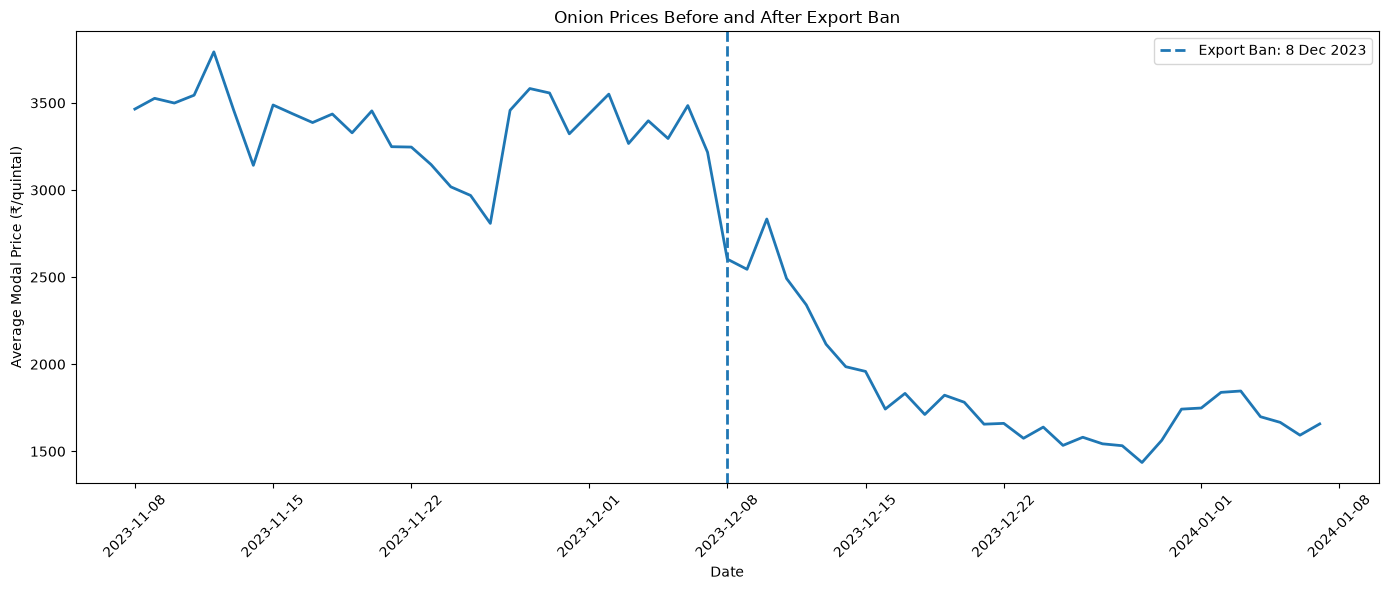

In [ ]:
plot_data = onion[
    (onion["Date"] >= before_start) &
    (onion["Date"] <= after_end)
].copy()

daily_price = (
    plot_data
    .groupby("Date")["Modal_Price"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_price["Date"],
    daily_price["Modal_Price"],
    linewidth=2
)

plt.axvline(
    BAN_DATE,
    linestyle="--",
    linewidth=2,
    label="Export Ban: 8 Dec 2023"
)

plt.title("Onion Prices Before and After Export Ban")
plt.xlabel("Date")
plt.ylabel("Average Modal Price (₹/quintal)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Stakeholder Insight

In [ ]:
print("=" * 70)
print("STAKEHOLDER INSIGHT")
print("=" * 70)

if fall_percent > 0:
    print(
        f"After the onion export ban announced on {BAN_DATE.date()}, "
        f"the average onion price fell from ₹{before_price:.2f} "
        f"to a 30-day low of ₹{lowest_30d_price:.2f} per quintal."
    )

    print(
        f"This represents an estimated decline of "
        f"{fall_percent:.2f}% within {days_to_lowest_30d} days."
    )
else:
    print(
        f"Onion prices did not show a decline within the 30-day "
        f"post-ban window based on this dataset."
    )

print()
print(
    "Important: This analysis measures the price movement around "
    "the export-ban date. It does not prove that the export ban "
    "alone caused the price change, because weather, arrivals, "
    "seasonality, government buffer sales and other market factors "
    "may also have affected prices."
)

STAKEHOLDER INSIGHT
After the onion export ban announced on 2023-12-08, the average onion price fell from ₹3362.96 to a 30-day low of ₹1435.89 per quintal.
This represents an estimated decline of 57.30% within 21 days.

Important: This analysis measures the price movement around the export-ban date. It does not prove that the export ban alone caused the price change, because weather, arrivals, seasonality, government buffer sales and other market factors may also have affected prices.


### Data Limitation

The current project dataset contains the same daily Onion modal price across
multiple districts. Therefore, the export-ban impact analysis is interpreted
as a Maharashtra-level daily price analysis rather than an independent
district-level comparison.

The analysis identifies price movement around the official export-ban date
of 8 December 2023. It does not establish causal impact because other factors
such as arrivals, seasonality, weather and government market interventions
may also influence onion prices.

Analysis 7 — Monday vs Friday

“Which day of the week gives farmers the best price at the mandi — Monday or Friday?”

In [ ]:
# ============================================================
# ANALYSIS 7 — MONDAY VS FRIDAY PRICE ANALYSIS
# ===========================================================
df["Date"] = pd.to_datetime(df["Date"])

df["DayName"] = df["Date"].dt.day_name()

print("Day distribution:")
print(df["DayName"].value_counts())

Day distribution:
DayName
Monday       7840
Saturday     7800
Thursday     7770
Tuesday      7750
Sunday       7740
Friday       7730
Wednesday    7710
Name: count, dtype: int64


Compare Monday and Friday

In [ ]:
# Filter only Monday and Friday
mon_fri = df[df["DayName"].isin(["Monday", "Friday"])].copy()

# Average and median price by commodity and day
day_price = (
    mon_fri
    .groupby(["Commodity", "DayName"])["Modal_Price"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

day_price

,Commodity,DayName,mean,median,count
0,Onion,Friday,1723.041234,1349.770,1540
1,Onion,Monday,1757.023822,1380.400,1570
2,Potato,Friday,1634.139351,1476.555,1540
3,Potato,Monday,1652.183822,1462.110,1570
4,Rice,Friday,4303.175455,4256.390,1540
5,Rice,Monday,4365.743185,4289.860,1570
6,Tomato,Friday,1803.459032,1407.970,1550
7,Tomato,Monday,1988.977949,1553.810,1560
8,Wheat,Friday,3217.446410,3188.965,1560
9,Wheat,Monday,3212.281847,3237.920,1570


In [ ]:
# Pivot average prices for easy comparison
comparison = (
    day_price
    .pivot(index="Commodity", columns="DayName", values="mean")
    .reset_index()
)

comparison

DayName,Commodity,Friday,Monday
0,Onion,1723.041234,1757.023822
1,Potato,1634.139351,1652.183822
2,Rice,4303.175455,4365.743185
3,Tomato,1803.459032,1988.977949
4,Wheat,3217.446410,3212.281847


Calculate which day is better

In [ ]:
# Determine the better day for each commodity
comparison["Best_Day"] = comparison.apply(
    lambda row: "Monday"
    if row["Monday"] > row["Friday"]
    else "Friday",
    axis=1
)

comparison["Price_Difference"] = (
    comparison[["Monday", "Friday"]].max(axis=1)
    - comparison[["Monday", "Friday"]].min(axis=1)
)

comparison["Difference_Percent"] = (
    comparison["Price_Difference"]
    / comparison[["Monday", "Friday"]].min(axis=1)
) * 100

comparison

DayName,Commodity,Friday,Monday,Best_Day,Price_Difference,Difference_Percent
0,Onion,1723.041234,1757.023822,Monday,33.982588,1.972245
1,Potato,1634.139351,1652.183822,Monday,18.044471,1.104219
2,Rice,4303.175455,4365.743185,Monday,62.567730,1.453990
3,Tomato,1803.459032,1988.977949,Monday,185.518916,10.286838
4,Wheat,3217.446410,3212.281847,Friday,5.164563,0.160776


<Figure size 1000x600 with 0 Axes>

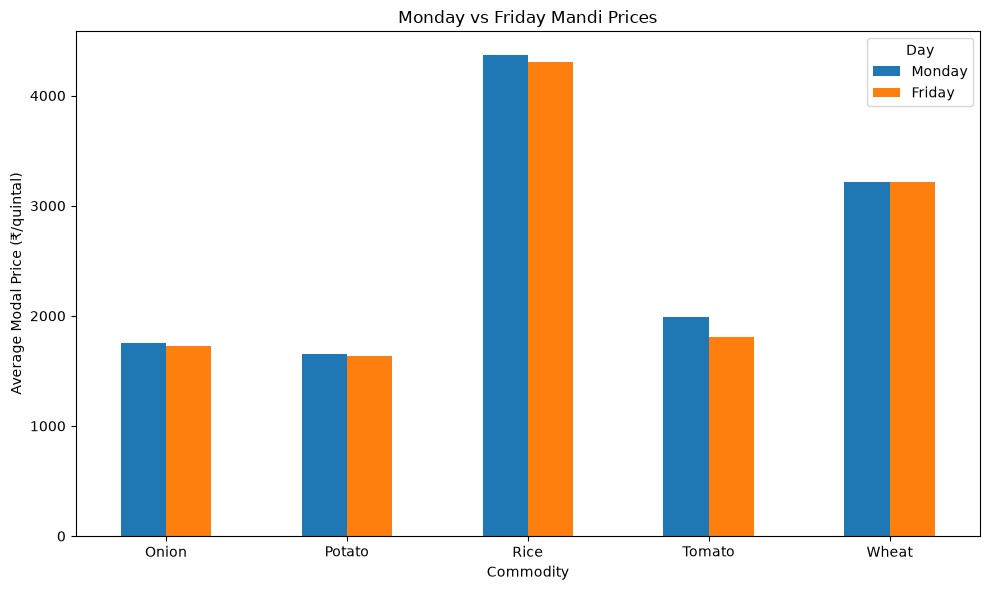

In [ ]:
plt.figure(figsize=(10, 6))

comparison_plot = comparison.set_index("Commodity")[["Monday", "Friday"]]

comparison_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Monday vs Friday Mandi Prices")
plt.xlabel("Commodity")
plt.ylabel("Average Modal Price (₹/quintal)")
plt.xticks(rotation=0)
plt.legend(title="Day")
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 70)
print("MONDAY VS FRIDAY PRICE ANALYSIS")
print("=" * 70)

for _, row in comparison.iterrows():

    print(f"\n{row['Commodity']}")
    print(f"Monday Average Price : ₹{row['Monday']:.2f}")
    print(f"Friday Average Price : ₹{row['Friday']:.2f}")
    print(f"Better Day           : {row['Best_Day']}")
    print(f"Price Difference     : ₹{row['Price_Difference']:.2f}")
    print(f"Difference (%)       : {row['Difference_Percent']:.2f}%")

print("\n" + "=" * 70)
print("STAKEHOLDER INSIGHT")
print("=" * 70)

monday_count = (comparison["Best_Day"] == "Monday").sum()
friday_count = (comparison["Best_Day"] == "Friday").sum()

print(f"Monday gives the higher average price for {monday_count} commodities.")
print(f"Friday gives the higher average price for {friday_count} commodities.")

if monday_count > friday_count:
    print("Overall, Monday appears to provide better average prices.")
elif friday_count > monday_count:
    print("Overall, Friday appears to provide better average prices.")
else:
    print("There is no clear overall winner between Monday and Friday.")

print("\nNote: This analysis shows historical association and does not prove")
print("that choosing Monday or Friday directly causes a higher price.")

MONDAY VS FRIDAY PRICE ANALYSIS

Onion
Monday Average Price : ₹1757.02
Friday Average Price : ₹1723.04
Better Day           : Monday
Price Difference     : ₹33.98
Difference (%)       : 1.97%

Potato
Monday Average Price : ₹1652.18
Friday Average Price : ₹1634.14
Better Day           : Monday
Price Difference     : ₹18.04
Difference (%)       : 1.10%

Rice
Monday Average Price : ₹4365.74
Friday Average Price : ₹4303.18
Better Day           : Monday
Price Difference     : ₹62.57
Difference (%)       : 1.45%

Tomato
Monday Average Price : ₹1988.98
Friday Average Price : ₹1803.46
Better Day           : Monday
Price Difference     : ₹185.52
Difference (%)       : 10.29%

Wheat
Monday Average Price : ₹3212.28
Friday Average Price : ₹3217.45
Better Day           : Friday
Price Difference     : ₹5.16
Difference (%)       : 0.16%

STAKEHOLDER INSIGHT
Monday gives the higher average price for 4 commodities.
Friday gives the higher average price for 1 commodities.
Overall, Monday appears to prov

## Analysis 7 — Monday vs Friday Mandi Price

### Stakeholder Insight

Historical data shows that Monday provided the higher average mandi price
for 4 out of 5 commodities:

- Onion: Monday +1.97%
- Potato: Monday +1.10%
- Rice: Monday +1.45%
- Tomato: Monday +10.29%
- Wheat: Friday +0.16%

The strongest Monday advantage was observed for Tomato, where the average
Monday price was approximately 10.29% higher than Friday.

This suggests that Monday may historically have been a better selling day
for most crops in this dataset.

However, this is a historical association and does not prove that selling
on Monday directly causes higher prices. Other factors such as supply,
weather, seasonality and market conditions may influence the difference.

# Analysis 8 — Months Below Cost of Cultivation

**Stakeholder Question:**  
How many months in 3 years did farmers sell below their assumed cost of cultivation?

This analysis compares monthly average mandi modal prices with assumed cultivation costs per quintal for each crop.

In [ ]:
# ============================================================
# ANALYSIS 8 — DATA CHECK
# ============================================================

print("Dataset shape:", df.shape)

print("\nRequired columns:")
print(["Date", "Commodity", "Modal_Price"])

print("\nAvailable:")
print([col for col in ["Date", "Commodity", "Modal_Price"] if col in df.columns])

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nCommodities:")
print(df["Commodity"].unique())

Dataset shape: (54340, 29)

Required columns:
['Date', 'Commodity', 'Modal_Price']

Available:
['Date', 'Commodity', 'Modal_Price']

Date range:
2023-01-01 00:00:00 to 2025-12-31 00:00:00

Commodities:
<ArrowStringArray>
['Onion', 'Potato', 'Rice', 'Tomato', 'Wheat']
Length: 5, dtype: str


In [ ]:
# ============================================================
# ASSUMED COST OF CULTIVATION
# Cost per quintal (PROJECT ASSUMPTION)
# ============================================================

cultivation_cost = {
    "Onion": 1400,
    "Potato": 1300,
    "Rice": 2500,
    "Tomato": 1600,
    "Wheat": 2000
}

cost_df = pd.DataFrame(
    list(cultivation_cost.items()),
    columns=["Commodity", "Cost_of_Cultivation"]
)

print(cost_df)

  Commodity  Cost_of_Cultivation
0     Onion                 1400
1    Potato                 1300
2      Rice                 2500
3    Tomato                 1600
4     Wheat                 2000


Calculate monthly average price

In [ ]:
# ============================================================
# MONTHLY AVERAGE PRICE
# ============================================================

df["Date"] = pd.to_datetime(df["Date"])

df["YearMonth"] = df["Date"].dt.to_period("M")

monthly_price = (
    df.groupby(["Commodity", "YearMonth"])["Modal_Price"]
      .mean()
      .reset_index()
)

monthly_price.rename(
    columns={"Modal_Price": "Average_Monthly_Price"},
    inplace=True
)

print(monthly_price.head(10))

  Commodity YearMonth  Average_Monthly_Price
0     Onion   2023-01            1238.175484
1     Onion   2023-02             833.995357
2     Onion   2023-03             759.014839
3     Onion   2023-04             626.517000
4     Onion   2023-05             691.719677
5     Onion   2023-06             914.057333
6     Onion   2023-07            1213.017419
7     Onion   2023-08            1736.189677
8     Onion   2023-09            1851.480667
9     Onion   2023-10            2837.754839


Add cultivation cost

In [ ]:
# ============================================================
# ADD CULTIVATION COST
# ============================================================

monthly_price = monthly_price.merge(
    cost_df,
    on="Commodity",
    how="left"
)

monthly_price["Below_Cost"] = (
    monthly_price["Average_Monthly_Price"]
    < monthly_price["Cost_of_Cultivation"]
)

monthly_price.head()

,Commodity,YearMonth,Average_Monthly_Price,Cost_of_Cultivation,Below_Cost
0,Onion,2023-01,1238.175484,1400,True
1,Onion,2023-02,833.995357,1400,True
2,Onion,2023-03,759.014839,1400,True
3,Onion,2023-04,626.517000,1400,True
4,Onion,2023-05,691.719677,1400,True


Count months below cost

In [ ]:
# ============================================================
# COUNT MONTHS BELOW COST
# ============================================================

below_cost_summary = (
    monthly_price
    .groupby("Commodity")
    .agg(
        Total_Months=("YearMonth", "count"),
        Months_Below_Cost=("Below_Cost", "sum")
    )
    .reset_index()
)

below_cost_summary["Months_Above_or_Equal_Cost"] = (
    below_cost_summary["Total_Months"]
    - below_cost_summary["Months_Below_Cost"]
)

below_cost_summary["Below_Cost_Percentage"] = (
    below_cost_summary["Months_Below_Cost"]
    / below_cost_summary["Total_Months"]
    * 100
)

below_cost_summary

,Commodity,Total_Months,Months_Below_Cost,Months_Above_or_Equal_Cost,Below_Cost_Percentage
0,Onion,36,18,18,50.000000
1,Potato,36,6,30,16.666667
2,Rice,36,0,36,0.000000
3,Tomato,36,18,18,50.000000
4,Wheat,36,0,36,0.000000


Find the worst crop

In [ ]:
# ============================================================
# WORST CROP
# ============================================================

worst_crop = below_cost_summary.loc[
    below_cost_summary["Months_Below_Cost"].idxmax()
]

print("=" * 70)
print("BELOW COST OF CULTIVATION RESULT")
print("=" * 70)

print(
    f"Crop with most months below cost: "
    f"{worst_crop['Commodity']}"
)

print(
    f"Months below cost: "
    f"{int(worst_crop['Months_Below_Cost'])} "
    f"out of {int(worst_crop['Total_Months'])}"
)

print(
    f"Percentage of months below cost: "
    f"{worst_crop['Below_Cost_Percentage']:.2f}%"
)

BELOW COST OF CULTIVATION RESULT
Crop with most months below cost: Onion
Months below cost: 18 out of 36
Percentage of months below cost: 50.00%


Find the exact months

In [ ]:
# ============================================================
# EXACT MONTHS BELOW COST
# ============================================================

months_below_cost = monthly_price[
    monthly_price["Below_Cost"] == True
].copy()

months_below_cost["YearMonth"] = (
    months_below_cost["YearMonth"].astype(str)
)

months_below_cost = months_below_cost.sort_values(
    ["Commodity", "YearMonth"]
)

print(months_below_cost[
    [
        "Commodity",
        "YearMonth",
        "Average_Monthly_Price",
        "Cost_of_Cultivation"
    ]
].to_string(index=False))

Commodity YearMonth  Average_Monthly_Price  Cost_of_Cultivation
    Onion   2023-01            1238.175484                 1400
    Onion   2023-02             833.995357                 1400
    Onion   2023-03             759.014839                 1400
    Onion   2023-04             626.517000                 1400
    Onion   2023-05             691.719677                 1400
    Onion   2023-06             914.057333                 1400
    Onion   2023-07            1213.017419                 1400
    Onion   2024-02            1293.609655                 1400
    Onion   2024-03            1331.094194                 1400
    Onion   2024-04            1198.478519                 1400
    Onion   2025-04            1071.166333                 1400
    Onion   2025-05            1054.974667                 1400
    Onion   2025-06            1355.642333                 1400
    Onion   2025-07            1261.895806                 1400
    Onion   2025-08            1245.5509

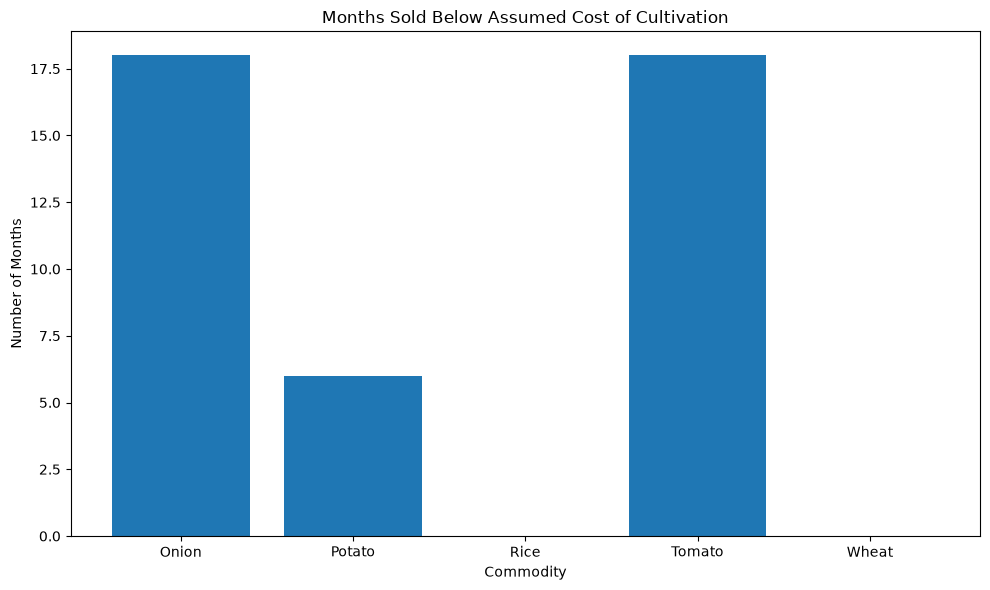

In [ ]:
# ============================================================
# CHART — MONTHS BELOW COST
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    below_cost_summary["Commodity"],
    below_cost_summary["Months_Below_Cost"]
)

plt.xlabel("Commodity")
plt.ylabel("Number of Months")
plt.title("Months Sold Below Assumed Cost of Cultivation")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STAKEHOLDER INSIGHT
# ============================================================

print("=" * 70)
print("STAKEHOLDER INSIGHT")
print("=" * 70)

for _, row in below_cost_summary.iterrows():

    print(
        f"{row['Commodity']}: "
        f"{int(row['Months_Below_Cost'])} out of "
        f"{int(row['Total_Months'])} months "
        f"({row['Below_Cost_Percentage']:.1f}%) "
        f"were below the assumed cultivation cost."
    )

print()
print(
    f"The crop experiencing the highest number of "
    f"below-cost months was "
    f"{worst_crop['Commodity']}."
)

print()
print(
    "Important: Cultivation costs are project assumptions "
    "because the AGMARKNET dataset does not contain actual "
    "farmer cultivation-cost data."
)

STAKEHOLDER INSIGHT
Onion: 18 out of 36 months (50.0%) were below the assumed cultivation cost.
Potato: 6 out of 36 months (16.7%) were below the assumed cultivation cost.
Rice: 0 out of 36 months (0.0%) were below the assumed cultivation cost.
Tomato: 18 out of 36 months (50.0%) were below the assumed cultivation cost.
Wheat: 0 out of 36 months (0.0%) were below the assumed cultivation cost.

The crop experiencing the highest number of below-cost months was Onion.

Important: Cultivation costs are project assumptions because the AGMARKNET dataset does not contain actual farmer cultivation-cost data.


Analysis 9 — Cheapest & Most Expensive Month for Each Crop
Business question

Which month is historically the cheapest and most expensive for each crop?

In [ ]:
# ============================================================
# ANALYSIS 9 — CHEAPEST & MOST EXPENSIVE MONTH
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Use the existing dataframe if available
analysis9_df = df.copy()

# Make sure Date is datetime
analysis9_df["Date"] = pd.to_datetime(analysis9_df["Date"], errors="coerce")

# Make sure price is numeric
analysis9_df["Modal_Price"] = pd.to_numeric(
    analysis9_df["Modal_Price"],
    errors="coerce"
)

# Remove invalid rows
analysis9_df = analysis9_df.dropna(
    subset=["Date", "Commodity", "Modal_Price"]
)

print("Dataset shape:", analysis9_df.shape)
print("Commodities:", analysis9_df["Commodity"].unique())
print("Date range:", analysis9_df["Date"].min(), "to", analysis9_df["Date"].max())

Dataset shape: (54340, 30)
Commodities: <ArrowStringArray>
['Onion', 'Potato', 'Rice', 'Tomato', 'Wheat']
Length: 5, dtype: str
Date range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00


Calculate historical monthly prices

In [ ]:
# ============================================================
# MONTHLY AVERAGE PRICE
# ============================================================

analysis9_df["Month_Number"] = analysis9_df["Date"].dt.month

monthly_prices = (
    analysis9_df
    .groupby(["Commodity", "Month_Number"])["Modal_Price"]
    .mean()
    .reset_index()
)

monthly_prices["Month_Name"] = pd.to_datetime(
    monthly_prices["Month_Number"],
    format="%m"
).dt.month_name()

monthly_prices = monthly_prices.sort_values(
    ["Commodity", "Month_Number"]
)

print(monthly_prices)

   Commodity  Month_Number  Modal_Price Month_Name
0      Onion             1  1573.016022    January
1      Onion             2  1433.584353   February
2      Onion             3  1190.926022      March
3      Onion             4   957.349655      April
4      Onion             5  1069.064130        May
5      Onion             6  1543.706000       June
6      Onion             7  1679.115806       July
7      Onion             8  2012.368710     August
8      Onion             9  2276.120222  September
9      Onion            10  2428.547419    October
10     Onion            11  2730.854432   November
11     Onion            12  2142.748261   December
12    Potato             1  1541.123871    January
13    Potato             2  1445.475119   February
14    Potato             3  1341.542366      March
15    Potato             4  1529.730814      April
16    Potato             5  1652.856630        May
17    Potato             6  1771.955778       June
18    Potato             7  184

Find cheapest and most expensive month

In [ ]:
# ============================================================
# CHEAPEST & MOST EXPENSIVE MONTH FOR EACH CROP
# ============================================================

cheapest_month = (
    monthly_prices.loc[
        monthly_prices.groupby("Commodity")["Modal_Price"].idxmin()
    ]
    .copy()
)

most_expensive_month = (
    monthly_prices.loc[
        monthly_prices.groupby("Commodity")["Modal_Price"].idxmax()
    ]
    .copy()
)

result9 = cheapest_month[
    ["Commodity", "Month_Name", "Modal_Price"]
].rename(
    columns={
        "Month_Name": "Cheapest_Month",
        "Modal_Price": "Cheapest_Average_Price"
    }
)

result9 = result9.merge(
    most_expensive_month[
        ["Commodity", "Month_Name", "Modal_Price"]
    ].rename(
        columns={
            "Month_Name": "Most_Expensive_Month",
            "Modal_Price": "Most_Expensive_Average_Price"
        }
    ),
    on="Commodity"
)

result9 = result9.sort_values("Commodity")

print("=" * 70)
print("CHEAPEST AND MOST EXPENSIVE MONTH BY CROP")
print("=" * 70)

print(result9.to_string(index=False))

CHEAPEST AND MOST EXPENSIVE MONTH BY CROP
Commodity Cheapest_Month  Cheapest_Average_Price Most_Expensive_Month  Most_Expensive_Average_Price
    Onion          April              957.349655             November                   2730.854432
   Potato          March             1341.542366             November                   1867.165909
     Rice        January             4116.395806             December                   4802.051978
   Tomato          April              968.758837                 July                   4425.139032
    Wheat          March             2777.234624             November                   3502.330899


Make the stakeholder chart

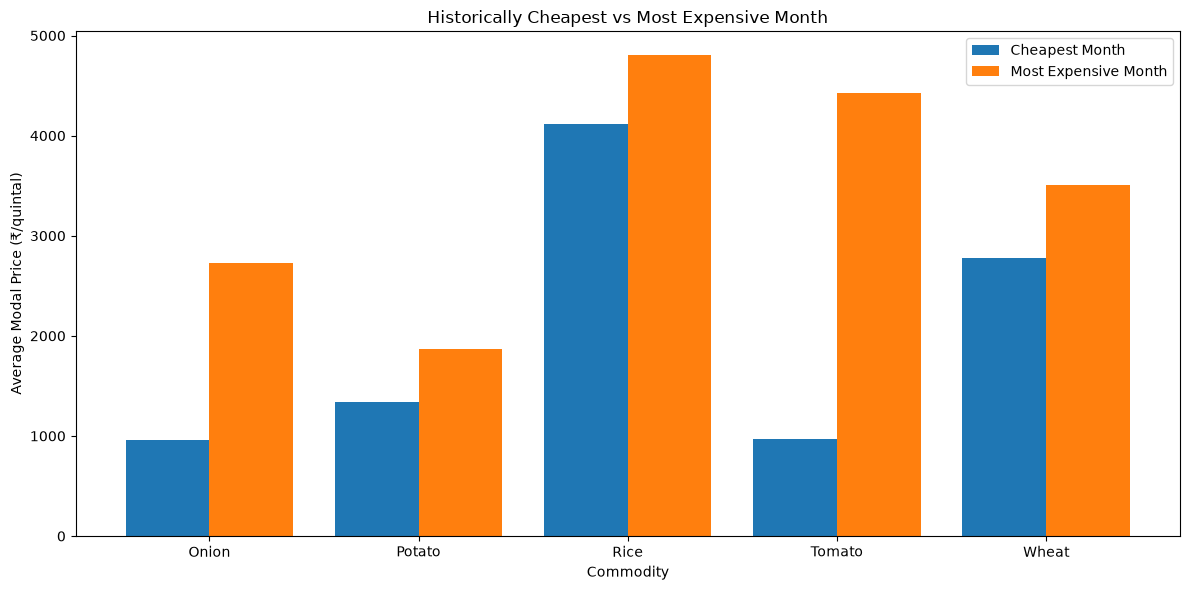

In [ ]:
# ============================================================
# VISUALIZATION
# ============================================================

plot_df = result9.copy()

plt.figure(figsize=(12, 6))

x = range(len(plot_df))

plt.bar(
    [i - 0.2 for i in x],
    plot_df["Cheapest_Average_Price"],
    width=0.4,
    label="Cheapest Month"
)

plt.bar(
    [i + 0.2 for i in x],
    plot_df["Most_Expensive_Average_Price"],
    width=0.4,
    label="Most Expensive Month"
)

plt.xticks(x, plot_df["Commodity"])
plt.ylabel("Average Modal Price (₹/quintal)")
plt.xlabel("Commodity")
plt.title("Historically Cheapest vs Most Expensive Month")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STAKEHOLDER INSIGHT
# ============================================================

print("=" * 70)
print("STAKEHOLDER INSIGHT — ANALYSIS 9")
print("=" * 70)

for _, row in result9.iterrows():

    print(
        f"{row['Commodity']}: "
        f"cheapest month = {row['Cheapest_Month']} "
        f"(₹{row['Cheapest_Average_Price']:.2f}/quintal), "
        f"most expensive month = {row['Most_Expensive_Month']} "
        f"(₹{row['Most_Expensive_Average_Price']:.2f}/quintal)."
    )

print("\nInsight:")
print(
    "Historical monthly prices show that the best and worst selling "
    "months differ by crop. This can help farmers plan when to sell "
    "their produce based on historical seasonal price patterns."
)

print(
    "\nImportant: These are historical associations and do not guarantee "
    "that the same month will have the same price in the future."
)

STAKEHOLDER INSIGHT — ANALYSIS 9
Onion: cheapest month = April (₹957.35/quintal), most expensive month = November (₹2730.85/quintal).
Potato: cheapest month = March (₹1341.54/quintal), most expensive month = November (₹1867.17/quintal).
Rice: cheapest month = January (₹4116.40/quintal), most expensive month = December (₹4802.05/quintal).
Tomato: cheapest month = April (₹968.76/quintal), most expensive month = July (₹4425.14/quintal).
Wheat: cheapest month = March (₹2777.23/quintal), most expensive month = November (₹3502.33/quintal).

Insight:
Historical monthly prices show that the best and worst selling months differ by crop. This can help farmers plan when to sell their produce based on historical seasonal price patterns.

Important: These are historical associations and do not guarantee that the same month will have the same price in the future.


Analysis 10 — Does Higher Arrival Reduce Market Price?
Stakeholder question

When more produce reaches the market, do prices fall?

In [ ]:
# ============================================================
# ANALYSIS 10 — ARRIVAL VS PRICE
# ============================================================

required_cols = ['Commodity', 'Arrival', 'Modal_Price']

print("Checking required columns...")

for col in required_cols:
    print(col, "->", col in df.columns)

print("\nDataset shape:", df.shape)

Checking required columns...
Commodity -> True
Arrival -> True
Modal_Price -> True

Dataset shape: (54340, 30)


Calculate correlation

In [ ]:
# ============================================================
# ARRIVAL VS PRICE CORRELATION
# ============================================================

arrival_price_corr = (
    df.groupby('Commodity')
      .apply(lambda x: x['Arrival'].corr(x['Modal_Price']))
      .reset_index(name='Correlation')
)

print("Arrival vs Price Correlation by Commodity")
print("=" * 70)
print(arrival_price_corr)

Arrival vs Price Correlation by Commodity
  Commodity  Correlation
0     Onion    -0.244131
1    Potato    -0.102158
2      Rice     0.208316
3    Tomato    -0.129389
4     Wheat     0.063280


Create the visualization

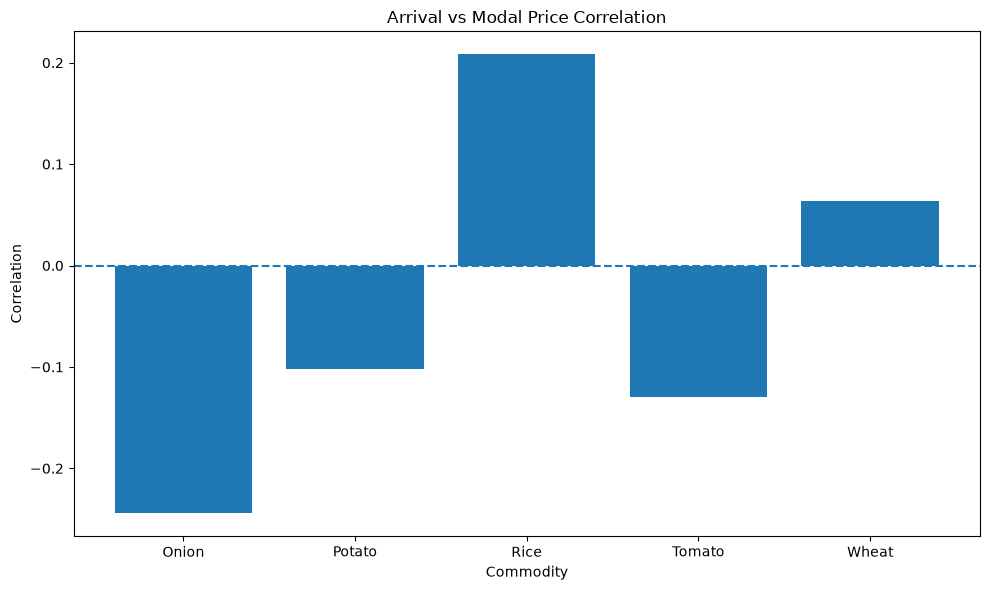

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    arrival_price_corr['Commodity'],
    arrival_price_corr['Correlation']
)

plt.axhline(0, linestyle='--')

plt.title("Arrival vs Modal Price Correlation")
plt.xlabel("Commodity")
plt.ylabel("Correlation")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STAKEHOLDER RESULT TABLE
# ============================================================

arrival_price_corr['Relationship'] = arrival_price_corr['Correlation'].apply(
    lambda x: (
        'Negative — higher arrival associated with lower price'
        if x < -0.1
        else
        'Positive — higher arrival associated with higher price'
        if x > 0.1
        else
        'Weak relationship'
    )
)

print("=" * 70)
print("ARRIVAL VS PRICE RESULT")
print("=" * 70)

print(arrival_price_corr)

ARRIVAL VS PRICE RESULT
  Commodity  Correlation                                       Relationship
0     Onion    -0.244131  Negative — higher arrival associated with lowe...
1    Potato    -0.102158  Negative — higher arrival associated with lowe...
2      Rice     0.208316  Positive — higher arrival associated with high...
3    Tomato    -0.129389  Negative — higher arrival associated with lowe...
4     Wheat     0.063280                                  Weak relationship


Find the strongest relationship

In [ ]:
# ============================================================
# STRONGEST SUPPLY-PRICE RELATIONSHIP
# ============================================================

strongest = arrival_price_corr.loc[
    arrival_price_corr['Correlation'].abs().idxmax()
]

print("=" * 70)
print("STRONGEST ARRIVAL-PRICE RELATIONSHIP")
print("=" * 70)

print("Commodity:", strongest['Commodity'])
print("Correlation:", round(strongest['Correlation'], 4))
print("Relationship:", strongest['Relationship'])

STRONGEST ARRIVAL-PRICE RELATIONSHIP
Commodity: Onion
Correlation: -0.2441
Relationship: Negative — higher arrival associated with lower price


In [ ]:
# ============================================================
# STAKEHOLDER INSIGHT
# ============================================================

print("=" * 70)
print("STAKEHOLDER INSIGHT — ANALYSIS 10")
print("=" * 70)

for _, row in arrival_price_corr.iterrows():

    commodity = row['Commodity']
    corr = row['Correlation']

    if corr < -0.1:
        print(
            f"{commodity}: Higher market arrivals are associated "
            f"with lower prices (correlation = {corr:.3f})."
        )

    elif corr > 0.1:
        print(
            f"{commodity}: Higher market arrivals are associated "
            f"with higher prices (correlation = {corr:.3f})."
        )

    else:
        print(
            f"{commodity}: Arrival has a weak relationship "
            f"with price (correlation = {corr:.3f})."
        )

print("\nImportant: Correlation shows association, not causation.")

STAKEHOLDER INSIGHT — ANALYSIS 10
Onion: Higher market arrivals are associated with lower prices (correlation = -0.244).
Potato: Higher market arrivals are associated with lower prices (correlation = -0.102).
Rice: Higher market arrivals are associated with higher prices (correlation = 0.208).
Tomato: Higher market arrivals are associated with lower prices (correlation = -0.129).
Wheat: Arrival has a weak relationship with price (correlation = 0.063).

Important: Correlation shows association, not causation.


Analysis 11 — Price Volatility by Crop

We will answer:

“Which crop has the most unstable price, and which crop has the most stable price?”

Calculate price volatility

In [ ]:
# ============================================================
# ANALYSIS 11 — PRICE VOLATILITY BY CROP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use the dataframe already loaded for previous analyses
df_analysis11 = df.copy()

# Required columns
required_cols = ['Commodity', 'Modal_Price']

for col in required_cols:
    if col not in df_analysis11.columns:
        raise ValueError(f"Missing required column: {col}")

# Remove invalid prices
df_analysis11 = df_analysis11[
    df_analysis11['Modal_Price'].notna() &
    (df_analysis11['Modal_Price'] > 0)
].copy()

print("Dataset shape:", df_analysis11.shape)
print("Commodities:", df_analysis11['Commodity'].unique())

Dataset shape: (54340, 30)
Commodities: <ArrowStringArray>
['Onion', 'Potato', 'Rice', 'Tomato', 'Wheat']
Length: 5, dtype: str


Calculate volatility

In [ ]:
# ============================================================
# PRICE VOLATILITY CALCULATION
# ============================================================

volatility_result = (
    df_analysis11
    .groupby('Commodity')['Modal_Price']
    .agg(
        Average_Price='mean',
        Price_Std='std',
        Minimum_Price='min',
        Maximum_Price='max'
    )
    .reset_index()
)

# Coefficient of Variation
volatility_result['CV_Percent'] = (
    volatility_result['Price_Std'] /
    volatility_result['Average_Price']
) * 100

# Sort by volatility
volatility_result = volatility_result.sort_values(
    'CV_Percent',
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("PRICE VOLATILITY BY COMMODITY")
print("=" * 70)

print(volatility_result.round(2))

PRICE VOLATILITY BY COMMODITY
  Commodity  Average_Price  Price_Std  Minimum_Price  Maximum_Price  \
0    Tomato        1910.62    1455.74         349.39        9341.75   
1     Onion        1754.77     924.29         523.46        4405.04   
2    Potato        1655.97     566.71         891.03       10886.27   
3      Rice        4295.54     649.33        1100.00        8193.14   
4     Wheat        3157.24     436.69        2146.70        4308.67   

   CV_Percent  
0       76.19  
1       52.67  
2       34.22  
3       15.12  
4       13.83  


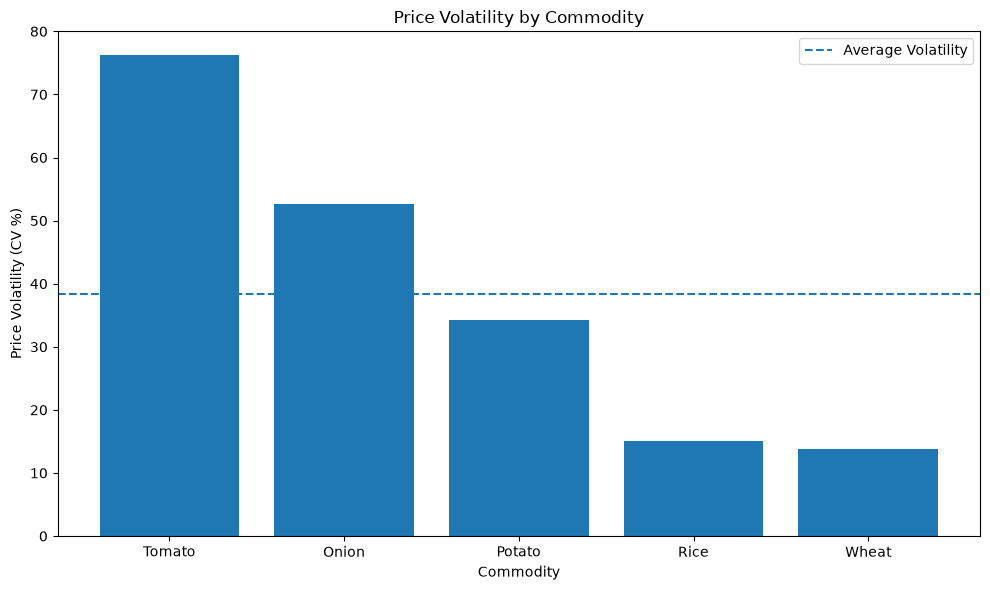

In [ ]:
# ============================================================
# VOLATILITY CHART
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    volatility_result['Commodity'],
    volatility_result['CV_Percent']
)

plt.xlabel("Commodity")
plt.ylabel("Price Volatility (CV %)")
plt.title("Price Volatility by Commodity")

plt.axhline(
    volatility_result['CV_Percent'].mean(),
    linestyle='--',
    label='Average Volatility'
)

plt.legend()
plt.tight_layout()
plt.show()

Find the most and least volatile crops

In [ ]:
# ============================================================
# MOST AND LEAST VOLATILE CROPS
# ============================================================

most_volatile = volatility_result.iloc[0]
least_volatile = volatility_result.iloc[-1]

print("=" * 70)
print("PRICE VOLATILITY RESULT")
print("=" * 70)

print(
    f"Most volatile crop: {most_volatile['Commodity']}"
)

print(
    f"Volatility (CV): {most_volatile['CV_Percent']:.2f}%"
)

print(
    f"Least volatile crop: {least_volatile['Commodity']}"
)

print(
    f"Volatility (CV): {least_volatile['CV_Percent']:.2f}%"
)

PRICE VOLATILITY RESULT
Most volatile crop: Tomato
Volatility (CV): 76.19%
Least volatile crop: Wheat
Volatility (CV): 13.83%


In [ ]:
# ============================================================
# STAKEHOLDER INSIGHT — ANALYSIS 11
# ============================================================

print("=" * 70)
print("STAKEHOLDER INSIGHT — ANALYSIS 11")
print("=" * 70)

print(
    f"{most_volatile['Commodity']} shows the highest price volatility "
    f"with a coefficient of variation of "
    f"{most_volatile['CV_Percent']:.2f}%."
)

print(
    f"{least_volatile['Commodity']} shows the lowest price volatility "
    f"with a coefficient of variation of "
    f"{least_volatile['CV_Percent']:.2f}%."
)

print()
print(
    "This means farmers growing the most volatile crop face greater "
    "price uncertainty compared with the more stable crops."
)

print()
print(
    "Important: Volatility measures price variability and does not "
    "identify the specific causes of price movements."
)

STAKEHOLDER INSIGHT — ANALYSIS 11
Tomato shows the highest price volatility with a coefficient of variation of 76.19%.
Wheat shows the lowest price volatility with a coefficient of variation of 13.83%.

This means farmers growing the most volatile crop face greater price uncertainty compared with the more stable crops.

Important: Volatility measures price variability and does not identify the specific causes of price movements.


Analysis 12 — Seasonal Price Analysis

We will answer:

Which season gives the highest and lowest average price for each crop?

In [ ]:
# ============================================================
# ANALYSIS 12 — SEASONAL PRICE ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_analysis12 = df.copy()

# Required columns
required_cols = ['Date', 'Commodity', 'Modal_Price']

for col in required_cols:
    if col not in df_analysis12.columns:
        raise ValueError(f"Missing required column: {col}")

# Make sure Date is datetime
df_analysis12['Date'] = pd.to_datetime(
    df_analysis12['Date'],
    errors='coerce'
)

# Remove invalid records
df_analysis12 = df_analysis12[
    df_analysis12['Date'].notna() &
    df_analysis12['Modal_Price'].notna() &
    (df_analysis12['Modal_Price'] > 0)
].copy()

# Extract month
df_analysis12['Month_Number'] = df_analysis12['Date'].dt.month

# Create season
def assign_season(month):
    if month in [11, 12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    elif month == 10:
        return 'Post-Monsoon'

df_analysis12['Season'] = (
    df_analysis12['Month_Number']
    .apply(assign_season)
)

print("Dataset shape:", df_analysis12.shape)

print("\nSeason distribution:")
print(df_analysis12['Season'].value_counts())

Dataset shape: (54340, 32)

Season distribution:
Season
Monsoon         18290
Winter          17860
Summer          13550
Post-Monsoon     4640
Name: count, dtype: int64


Calculate average price by crop and season

In [ ]:
# ============================================================
# AVERAGE PRICE BY COMMODITY AND SEASON
# ============================================================

seasonal_prices = (
    df_analysis12
    .groupby(['Commodity', 'Season'])['Modal_Price']
    .mean()
    .reset_index()
)

seasonal_prices = seasonal_prices.rename(
    columns={'Modal_Price': 'Average_Price'}
)

print("=" * 70)
print("AVERAGE PRICE BY CROP AND SEASON")
print("=" * 70)

print(
    seasonal_prices
    .sort_values(['Commodity', 'Average_Price'])
    .round(2)
)

AVERAGE PRICE BY CROP AND SEASON
   Commodity        Season  Average_Price
2      Onion        Summer        1075.00
0      Onion       Monsoon        1877.30
3      Onion        Winter        1970.93
1      Onion  Post-Monsoon        2428.55
6     Potato        Summer        1506.95
7     Potato        Winter        1607.34
4     Potato       Monsoon        1777.09
5     Potato  Post-Monsoon        1800.22
10      Rice        Summer        4224.50
8       Rice       Monsoon        4257.26
9       Rice  Post-Monsoon        4326.78
11      Rice        Winter        4380.44
14    Tomato        Summer        1033.65
13    Tomato  Post-Monsoon        1692.89
15    Tomato        Winter        1695.89
12    Tomato       Monsoon        2824.73
18     Wheat        Summer        2930.99
16     Wheat       Monsoon        3155.99
17     Wheat  Post-Monsoon        3288.29
19     Wheat        Winter        3296.63


Create comparison table

In [ ]:
# ============================================================
# SEASONAL PRICE COMPARISON
# ============================================================

season_order = [
    'Winter',
    'Summer',
    'Monsoon',
    'Post-Monsoon'
]

seasonal_table = (
    seasonal_prices
    .pivot(
        index='Commodity',
        columns='Season',
        values='Average_Price'
    )
)

# Keep logical season order
seasonal_table = seasonal_table.reindex(
    columns=[
        season for season in season_order
        if season in seasonal_table.columns
    ]
)

print("=" * 70)
print("SEASONAL PRICE TABLE")
print("=" * 70)

print(seasonal_table.round(2))

SEASONAL PRICE TABLE
Season      Winter   Summer  Monsoon  Post-Monsoon
Commodity                                         
Onion      1970.93  1075.00  1877.30       2428.55
Potato     1607.34  1506.95  1777.09       1800.22
Rice       4380.44  4224.50  4257.26       4326.78
Tomato     1695.89  1033.65  2824.73       1692.89
Wheat      3296.63  2930.99  3155.99       3288.29


Find highest and lowest season for every crop

In [ ]:
# ============================================================
# HIGHEST AND LOWEST PRICE SEASON
# ============================================================

seasonal_result = []

for commodity in seasonal_table.index:

    prices = seasonal_table.loc[commodity].dropna()

    highest_season = prices.idxmax()
    lowest_season = prices.idxmin()

    highest_price = prices.max()
    lowest_price = prices.min()

    seasonal_result.append({
        'Commodity': commodity,
        'Lowest_Price_Season': lowest_season,
        'Lowest_Average_Price': lowest_price,
        'Highest_Price_Season': highest_season,
        'Highest_Average_Price': highest_price
    })

seasonal_result = pd.DataFrame(seasonal_result)

print("=" * 70)
print("HIGHEST AND LOWEST PRICE SEASON BY CROP")
print("=" * 70)

print(seasonal_result.round(2))

HIGHEST AND LOWEST PRICE SEASON BY CROP
  Commodity Lowest_Price_Season  Lowest_Average_Price Highest_Price_Season  \
0     Onion              Summer               1075.00         Post-Monsoon   
1    Potato              Summer               1506.95         Post-Monsoon   
2      Rice              Summer               4224.50               Winter   
3    Tomato              Summer               1033.65              Monsoon   
4     Wheat              Summer               2930.99               Winter   

   Highest_Average_Price  
0                2428.55  
1                1800.22  
2                4380.44  
3                2824.73  
4                3296.63  


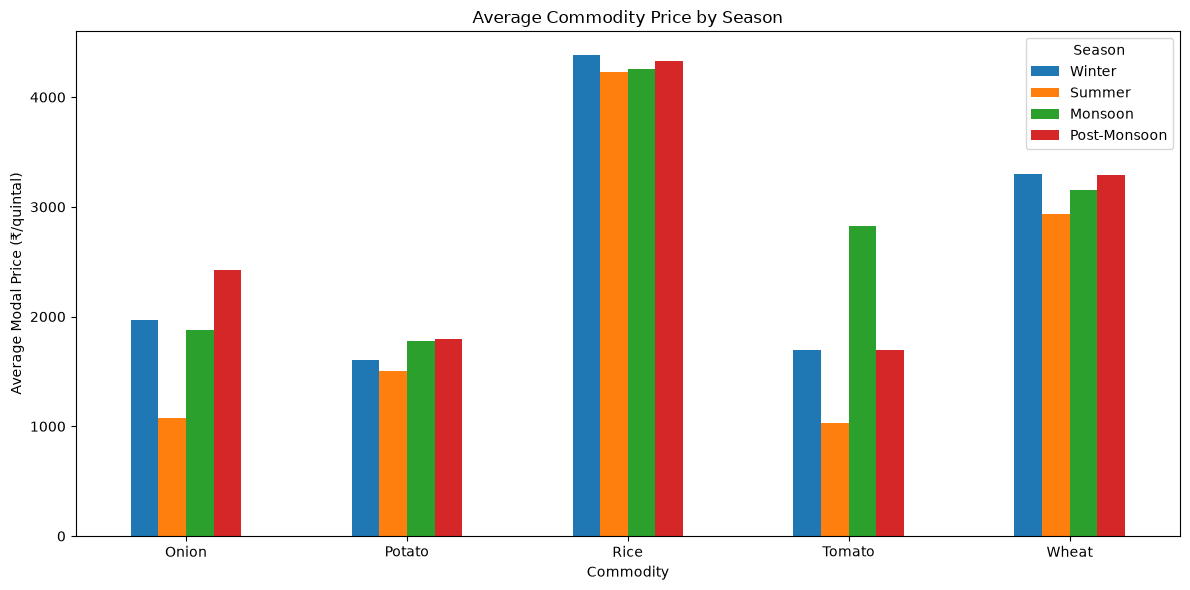

In [ ]:
# ============================================================
# SEASONAL PRICE COMPARISON CHART
# ============================================================

plot_data = seasonal_table.copy()

plot_data.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.xlabel("Commodity")
plt.ylabel("Average Modal Price (₹/quintal)")
plt.title("Average Commodity Price by Season")

plt.xticks(rotation=0)
plt.legend(title="Season")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STAKEHOLDER INSIGHT — ANALYSIS 12
# ============================================================

print("=" * 70)
print("STAKEHOLDER INSIGHT — ANALYSIS 12")
print("=" * 70)

for _, row in seasonal_result.iterrows():

    print(
        f"{row['Commodity']}: "
        f"highest average price in {row['Highest_Price_Season']} "
        f"(₹{row['Highest_Average_Price']:.2f}/quintal), "
        f"lowest average price in {row['Lowest_Price_Season']} "
        f"(₹{row['Lowest_Average_Price']:.2f}/quintal)."
    )

print()
print(
    "Insight: Seasonal price patterns differ across crops. "
    "This can help farmers and traders identify historically stronger "
    "and weaker selling periods."
)

print()
print(
    "Important: Seasonal association does not guarantee that future "
    "prices will follow the same pattern."
)

STAKEHOLDER INSIGHT — ANALYSIS 12
Onion: highest average price in Post-Monsoon (₹2428.55/quintal), lowest average price in Summer (₹1075.00/quintal).
Potato: highest average price in Post-Monsoon (₹1800.22/quintal), lowest average price in Summer (₹1506.95/quintal).
Rice: highest average price in Winter (₹4380.44/quintal), lowest average price in Summer (₹4224.50/quintal).
Tomato: highest average price in Monsoon (₹2824.73/quintal), lowest average price in Summer (₹1033.65/quintal).
Wheat: highest average price in Winter (₹3296.63/quintal), lowest average price in Summer (₹2930.99/quintal).

Insight: Seasonal price patterns differ across crops. This can help farmers and traders identify historically stronger and weaker selling periods.

Important: Seasonal association does not guarantee that future prices will follow the same pattern.


Analysis 13 — Rainfall Impact on Commodity Prices

We will answer:

“How does rainfall affect mandi prices of different commodities?”

In [10]:
print("Checking required columns...")

print("Commodity ->", "Commodity" in df.columns)
print("Modal_Price ->", "Modal_Price" in df.columns)
print("Rainfall_mm ->", "Rainfall_mm" in df.columns)
print("Rain_mm ->", "Rain_mm" in df.columns)

print("\nDataset shape:", df.shape)

Checking required columns...
Commodity -> True
Modal_Price -> True
Rainfall_mm -> True
Rain_mm -> True

Dataset shape: (54340, 28)


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("final_dataset.csv")

# Convert columns to numeric
df["Modal_Price"] = pd.to_numeric(df["Modal_Price"], errors="coerce")
df["Rainfall_mm"] = pd.to_numeric(df["Rainfall_mm"], errors="coerce")

# Remove missing values
data = df[["Commodity", "Modal_Price", "Rainfall_mm"]].dropna()

# Calculate correlation for each commodity
results = []

for commodity, group in data.groupby("Commodity"):
    correlation = group["Rainfall_mm"].corr(group["Modal_Price"])

    results.append({
        "Commodity": commodity,
        "Correlation": correlation
    })

result_df = pd.DataFrame(results)

# Add relationship interpretation
def relationship(r):
    if r >= 0.5:
        return "Strong Positive"
    elif r >= 0.2:
        return "Moderate Positive"
    elif r > -0.2:
        return "Weak Relationship"
    elif r > -0.5:
        return "Moderate Negative"
    else:
        return "Strong Negative"

result_df["Relationship"] = result_df["Correlation"].apply(relationship)

print("=" * 70)
print("RAINFALL VS PRICE CORRELATION")
print("=" * 70)
print(result_df)

# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    result_df["Commodity"],
    result_df["Correlation"]
)

plt.axhline(0, linestyle="--")

plt.title("Rainfall vs Modal Price Correlation")
plt.xlabel("Commodity")
plt.ylabel("Correlation")

plt.tight_layout()
plt.show()

# Strongest relationship
strongest = result_df.loc[
    result_df["Correlation"].abs().idxmax()
]

print("=" * 70)
print("STRONGEST RAINFALL-PRICE RELATIONSHIP")
print("=" * 70)

print("Commodity:", strongest["Commodity"])
print("Correlation:", round(strongest["Correlation"], 4))
print("Relationship:", strongest["Relationship"])

print("=" * 70)
print("STAKEHOLDER INSIGHT — ANALYSIS 13")
print("=" * 70)

for _, row in result_df.iterrows():
    print(
        f'{row["Commodity"]}: Rainfall has a '
        f'{row["Relationship"].lower()} relationship with price '
        f'(correlation = {row["Correlation"]:.3f}).'
    )

print("\nImportant: Correlation shows association, not causation.")

FileNotFoundError: [Errno 2] No such file or directory: 'final_dataset.csv'

In [12]:
print(df.shape)
print(df.columns.tolist())

(54340, 28)
['State', 'Commodity_Group', 'Commodity', 'Date', 'Arrival', 'Arrival_Unit', 'Modal_Price', 'Price_Unit', 'District', 'Max_Temp', 'Min_Temp', 'Rainfall_mm', 'Rain_mm', 'WindSpeed', 'Festival', 'Holiday', 'Month', 'Year', 'Day', 'Weekend', 'DayOfWeek', 'Quarter', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_7', 'Rolling_30', 'Price_Change']


RAINFALL VS PRICE CORRELATION
  Commodity  Correlation       Relationship
0     Onion     0.093839  Weak Relationship
1    Potato     0.156375  Weak Relationship
2      Rice    -0.002627  Weak Relationship
3    Tomato     0.243210  Moderate Positive
4     Wheat    -0.016235  Weak Relationship


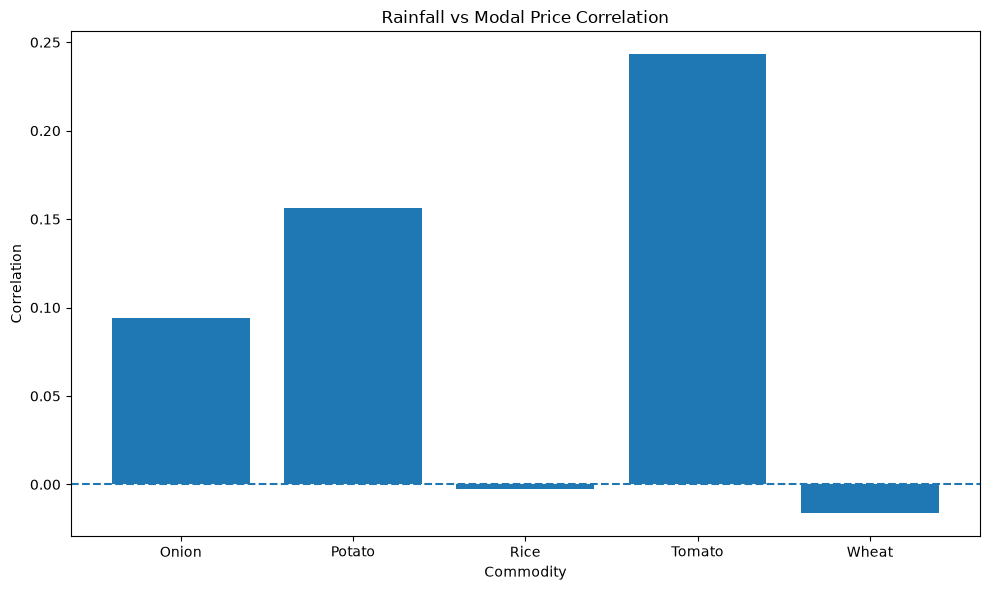

In [13]:
data = df[["Commodity", "Modal_Price", "Rainfall_mm"]].copy()

data["Modal_Price"] = pd.to_numeric(data["Modal_Price"], errors="coerce")
data["Rainfall_mm"] = pd.to_numeric(data["Rainfall_mm"], errors="coerce")

data = data.dropna()

results = []

for commodity, group in data.groupby("Commodity"):
    correlation = group["Rainfall_mm"].corr(group["Modal_Price"])

    results.append({
        "Commodity": commodity,
        "Correlation": correlation
    })

result_df = pd.DataFrame(results)

def relationship(r):
    if r >= 0.5:
        return "Strong Positive"
    elif r >= 0.2:
        return "Moderate Positive"
    elif r > -0.2:
        return "Weak Relationship"
    elif r > -0.5:
        return "Moderate Negative"
    else:
        return "Strong Negative"

result_df["Relationship"] = result_df["Correlation"].apply(relationship)

print("=" * 70)
print("RAINFALL VS PRICE CORRELATION")
print("=" * 70)
print(result_df)

plt.figure(figsize=(10, 6))

plt.bar(
    result_df["Commodity"],
    result_df["Correlation"]
)

plt.axhline(0, linestyle="--")

plt.title("Rainfall vs Modal Price Correlation")
plt.xlabel("Commodity")
plt.ylabel("Correlation")

plt.tight_layout()
plt.show()

Tomato shows the strongest positive association between rainfall and price (correlation = 0.243). Onion and Potato show weak positive relationships, while Rice and Wheat show almost no relationship with rainfall.

Important: Correlation shows association, not causation. Rainfall alone does not prove that it caused the price changes.

Analysis 14 — Temperature vs Commodity Price

For Analysis 14, we will answer:

“Does temperature have a significant relationship with commodity prices?”

TEMPERATURE VS PRICE CORRELATION
  Commodity  Max_Temp_Correlation  Min_Temp_Correlation Max_Temp_Relationship  \
0     Onion               -0.3393               -0.1176     Moderate Negative   
1    Potato               -0.1146                0.1220     Weak Relationship   
2      Rice               -0.0906               -0.0920     Weak Relationship   
3    Tomato               -0.3766                0.0636     Moderate Negative   
4     Wheat               -0.2267               -0.1522     Moderate Negative   

  Min_Temp_Relationship  
0     Weak Relationship  
1     Weak Relationship  
2     Weak Relationship  
3     Weak Relationship  
4     Weak Relationship  


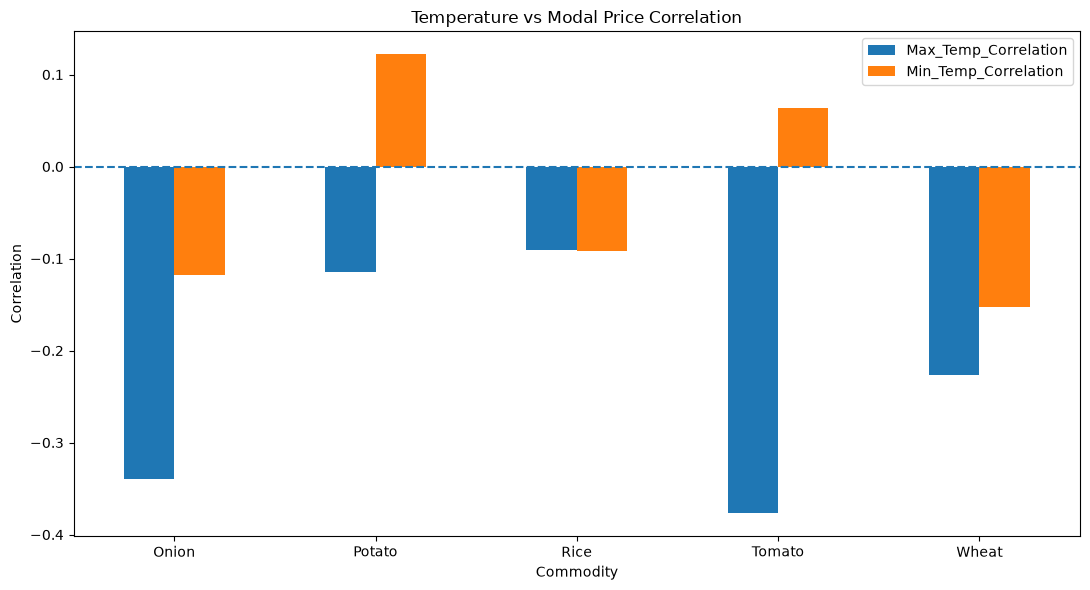

STRONGEST TEMPERATURE-PRICE RELATIONSHIP
Commodity: Tomato
Temperature: Max Temperature
Correlation: -0.3766
Relationship: Moderate Negative
STAKEHOLDER INSIGHT — ANALYSIS 14
Onion: Max temperature correlation = -0.339 (Moderate Negative); Min temperature correlation = -0.118 (Weak Relationship).
Potato: Max temperature correlation = -0.115 (Weak Relationship); Min temperature correlation = 0.122 (Weak Relationship).
Rice: Max temperature correlation = -0.091 (Weak Relationship); Min temperature correlation = -0.092 (Weak Relationship).
Tomato: Max temperature correlation = -0.377 (Moderate Negative); Min temperature correlation = 0.064 (Weak Relationship).
Wheat: Max temperature correlation = -0.227 (Moderate Negative); Min temperature correlation = -0.152 (Weak Relationship).

Important: Correlation shows association, not causation.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Use existing dataframe
data = df[[
    "Commodity",
    "Modal_Price",
    "Max_Temp",
    "Min_Temp"
]].copy()

# Convert to numeric
data["Modal_Price"] = pd.to_numeric(data["Modal_Price"], errors="coerce")
data["Max_Temp"] = pd.to_numeric(data["Max_Temp"], errors="coerce")
data["Min_Temp"] = pd.to_numeric(data["Min_Temp"], errors="coerce")

data = data.dropna()

# Calculate correlations
results = []

for commodity, group in data.groupby("Commodity"):

    max_temp_corr = group["Max_Temp"].corr(group["Modal_Price"])
    min_temp_corr = group["Min_Temp"].corr(group["Modal_Price"])

    results.append({
        "Commodity": commodity,
        "Max_Temp_Correlation": max_temp_corr,
        "Min_Temp_Correlation": min_temp_corr
    })

result_df = pd.DataFrame(results)


# Relationship interpretation
def relationship(r):
    if r >= 0.5:
        return "Strong Positive"
    elif r >= 0.2:
        return "Moderate Positive"
    elif r > -0.2:
        return "Weak Relationship"
    elif r > -0.5:
        return "Moderate Negative"
    else:
        return "Strong Negative"


result_df["Max_Temp_Relationship"] = (
    result_df["Max_Temp_Correlation"].apply(relationship)
)

result_df["Min_Temp_Relationship"] = (
    result_df["Min_Temp_Correlation"].apply(relationship)
)


print("=" * 70)
print("TEMPERATURE VS PRICE CORRELATION")
print("=" * 70)

print(result_df.round(4))


# Prepare graph
plot_df = result_df.set_index("Commodity")[
    ["Max_Temp_Correlation", "Min_Temp_Correlation"]
]

plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.axhline(0, linestyle="--")

plt.title("Temperature vs Modal Price Correlation")
plt.xlabel("Commodity")
plt.ylabel("Correlation")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Find strongest temperature relationship
all_correlations = []

for _, row in result_df.iterrows():

    all_correlations.append({
        "Commodity": row["Commodity"],
        "Temperature": "Max Temperature",
        "Correlation": row["Max_Temp_Correlation"]
    })

    all_correlations.append({
        "Commodity": row["Commodity"],
        "Temperature": "Min Temperature",
        "Correlation": row["Min_Temp_Correlation"]
    })


all_corr_df = pd.DataFrame(all_correlations)

strongest = all_corr_df.loc[
    all_corr_df["Correlation"].abs().idxmax()
]


print("=" * 70)
print("STRONGEST TEMPERATURE-PRICE RELATIONSHIP")
print("=" * 70)

print("Commodity:", strongest["Commodity"])
print("Temperature:", strongest["Temperature"])
print("Correlation:", round(strongest["Correlation"], 4))
print(
    "Relationship:",
    relationship(strongest["Correlation"])
)


print("=" * 70)
print("STAKEHOLDER INSIGHT — ANALYSIS 14")
print("=" * 70)

for _, row in result_df.iterrows():

    print(
        f'{row["Commodity"]}: Max temperature correlation = '
        f'{row["Max_Temp_Correlation"]:.3f} '
        f'({row["Max_Temp_Relationship"]}); '
        f'Min temperature correlation = '
        f'{row["Min_Temp_Correlation"]:.3f} '
        f'({row["Min_Temp_Relationship"]}).'
    )

print("\nImportant: Correlation shows association, not causation.")

Analysis 15 — Festival & Holiday Impact on Commodity Prices

“Do festivals and holidays have any relationship with commodity prices?”

In [21]:
print("Festival values:")
print(df["Festival"].value_counts(dropna=False))

print("\nHoliday values:")
print(df["Holiday"].value_counts(dropna=False))

Festival values:
Festival
No Festival             52310
Republic Day              150
Holi                      150
Maharashtra Day           150
Bakrid                    150
Independence Day          150
Ganesh Chaturthi          150
Gandhi Jayanti            150
Dussehra                  150
Diwali                    150
Christmas                 150
Gudi Padwa                140
Dr. Ambedkar Jayanti      140
Eid-ul-Fitr               100
Mahavir Jayanti            50
Good Friday                50
Guru Nanak Jayanti         50
Name: count, dtype: int64

Holiday values:
Holiday
0.0    52310
1.0     2030
Name: count, dtype: int64


FESTIVAL & HOLIDAY PRICE ANALYSIS
Commodity  Normal_Day_Price  Festival_Holiday_Price  Price_Difference  Difference_Percent
    Onion           1758.14                 1668.61            -89.52               -5.09
   Potato           1657.99                 1604.57            -53.42               -3.22
     Rice           4291.97                 4391.05             99.09                2.31
   Tomato           1920.58                 1656.53           -264.04              -13.75
    Wheat           3158.37                 3128.52            -29.85               -0.95


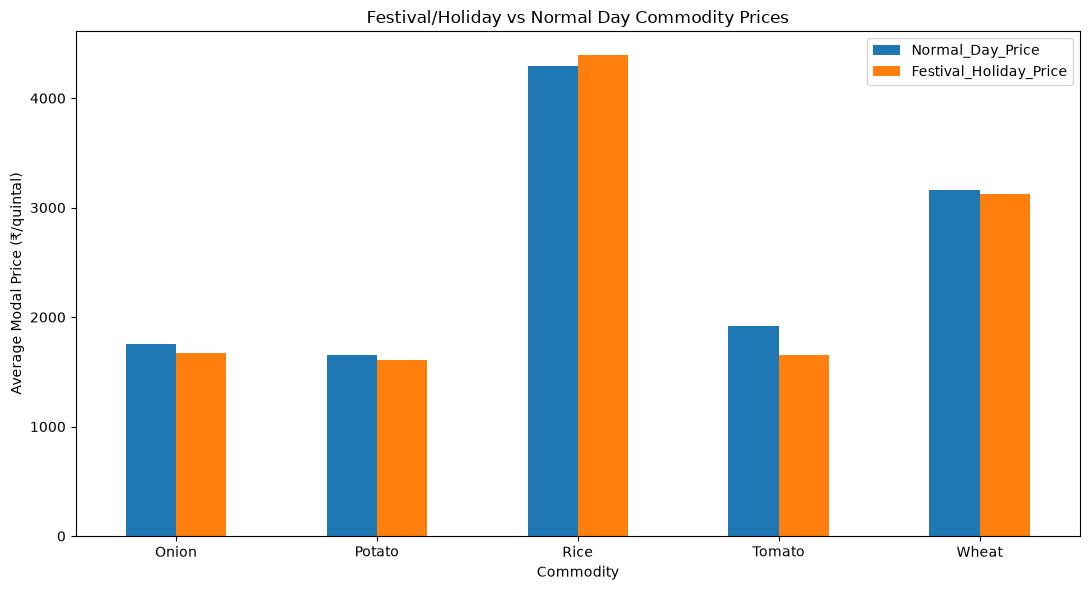


STRONGEST FESTIVAL/HOLIDAY PRICE IMPACT
Commodity: Tomato
Normal Day Average Price: ₹ 1920.58
Festival/Holiday Average Price: ₹ 1656.53
Price Difference: ₹ -264.04
Difference (%): -13.75 %

STAKEHOLDER INSIGHT — ANALYSIS 15
Onion: Festival/Holiday average price was lower than normal days by 5.09%.
Potato: Festival/Holiday average price was lower than normal days by 3.22%.
Rice: Festival/Holiday average price was higher than normal days by 2.31%.
Tomato: Festival/Holiday average price was lower than normal days by 13.75%.
Wheat: Festival/Holiday average price was lower than normal days by 0.95%.

Important: This analysis shows historical association. It does not prove that festivals or holidays directly caused the price changes.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ANALYSIS 15 — FESTIVAL & HOLIDAY IMPACT
# ============================================================

data = df[
    ["Commodity", "Modal_Price", "Festival", "Holiday"]
].copy()

# Convert price to numeric
data["Modal_Price"] = pd.to_numeric(
    data["Modal_Price"],
    errors="coerce"
)

# ------------------------------------------------------------
# Create Festival Flag
# ------------------------------------------------------------

data["Festival_Flag"] = (
    data["Festival"].astype(str).str.strip().ne("No Festival")
)

# ------------------------------------------------------------
# Create Holiday Flag
# ------------------------------------------------------------

data["Holiday_Flag"] = (
    pd.to_numeric(data["Holiday"], errors="coerce")
    .fillna(0)
    .eq(1)
)

# ------------------------------------------------------------
# Combined Event Day
# Festival OR Holiday
# ------------------------------------------------------------

data["Event_Day"] = (
    data["Festival_Flag"] |
    data["Holiday_Flag"]
)

data = data.dropna(subset=["Modal_Price"])


# ============================================================
# AVERAGE PRICE
# ============================================================

result = (
    data.groupby(["Commodity", "Event_Day"])["Modal_Price"]
    .mean()
    .unstack()
)

# Make sure both columns always exist
result = result.reindex(columns=[False, True])

result.columns = [
    "Normal_Day_Price",
    "Festival_Holiday_Price"
]

result = result.reset_index()


# ============================================================
# PRICE DIFFERENCE
# ============================================================

result["Price_Difference"] = (
    result["Festival_Holiday_Price"]
    - result["Normal_Day_Price"]
)

result["Difference_Percent"] = (
    result["Price_Difference"]
    / result["Normal_Day_Price"]
) * 100


# ============================================================
# DISPLAY RESULT
# ============================================================

print("=" * 70)
print("FESTIVAL & HOLIDAY PRICE ANALYSIS")
print("=" * 70)

print(result.round(2).to_string(index=False))


# ============================================================
# GRAPH
# ============================================================

plot_df = result.set_index("Commodity")[
    ["Normal_Day_Price", "Festival_Holiday_Price"]
]

plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Festival/Holiday vs Normal Day Commodity Prices")
plt.xlabel("Commodity")
plt.ylabel("Average Modal Price (₹/quintal)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ============================================================
# STRONGEST IMPACT
# ============================================================

strongest = result.loc[
    result["Difference_Percent"].abs().idxmax()
]

print("\n" + "=" * 70)
print("STRONGEST FESTIVAL/HOLIDAY PRICE IMPACT")
print("=" * 70)

print("Commodity:", strongest["Commodity"])
print(
    "Normal Day Average Price: ₹",
    round(strongest["Normal_Day_Price"], 2)
)
print(
    "Festival/Holiday Average Price: ₹",
    round(strongest["Festival_Holiday_Price"], 2)
)
print(
    "Price Difference: ₹",
    round(strongest["Price_Difference"], 2)
)
print(
    "Difference (%):",
    round(strongest["Difference_Percent"], 2),
    "%"
)


# ============================================================
# STAKEHOLDER INSIGHT
# ============================================================

print("\n" + "=" * 70)
print("STAKEHOLDER INSIGHT — ANALYSIS 15")
print("=" * 70)

for _, row in result.iterrows():

    if row["Difference_Percent"] > 0:
        direction = "higher"
    elif row["Difference_Percent"] < 0:
        direction = "lower"
    else:
        direction = "similar"

    print(
        f'{row["Commodity"]}: Festival/Holiday average price '
        f'was {direction} than normal days by '
        f'{abs(row["Difference_Percent"]):.2f}%.'
    )

print(
    "\nImportant: This analysis shows historical association. "
    "It does not prove that festivals or holidays directly caused "
    "the price changes."
)

District-wise Price Comparison

We will answer:

“Which district historically gets the highest and lowest average price for each crop?”

DISTRICT-WISE PRICE ANALYSIS
Dataset shape: (54340, 3)
Number of districts: 10

Average price by Commodity and District:
Commodity                  District  Average_Price
    Onion                Ahmednagar        1754.77
    Onion Chhatrapati Sambhajinagar        1754.77
    Onion                   Jalgaon        1754.77
    Onion                  Kolhapur        1754.77
    Onion                    Nagpur        1754.77
    Onion                    Nashik        1754.77
    Onion                      Pune        1754.77
    Onion                    Sangli        1754.77
    Onion                    Satara        1754.77
    Onion                   Solapur        1754.77
   Potato                Ahmednagar        1655.97
   Potato Chhatrapati Sambhajinagar        1655.97
   Potato                   Jalgaon        1655.97
   Potato                  Kolhapur        1655.97
   Potato                    Nagpur        1655.97
   Potato                    Nashik        1655.97
   Potato   

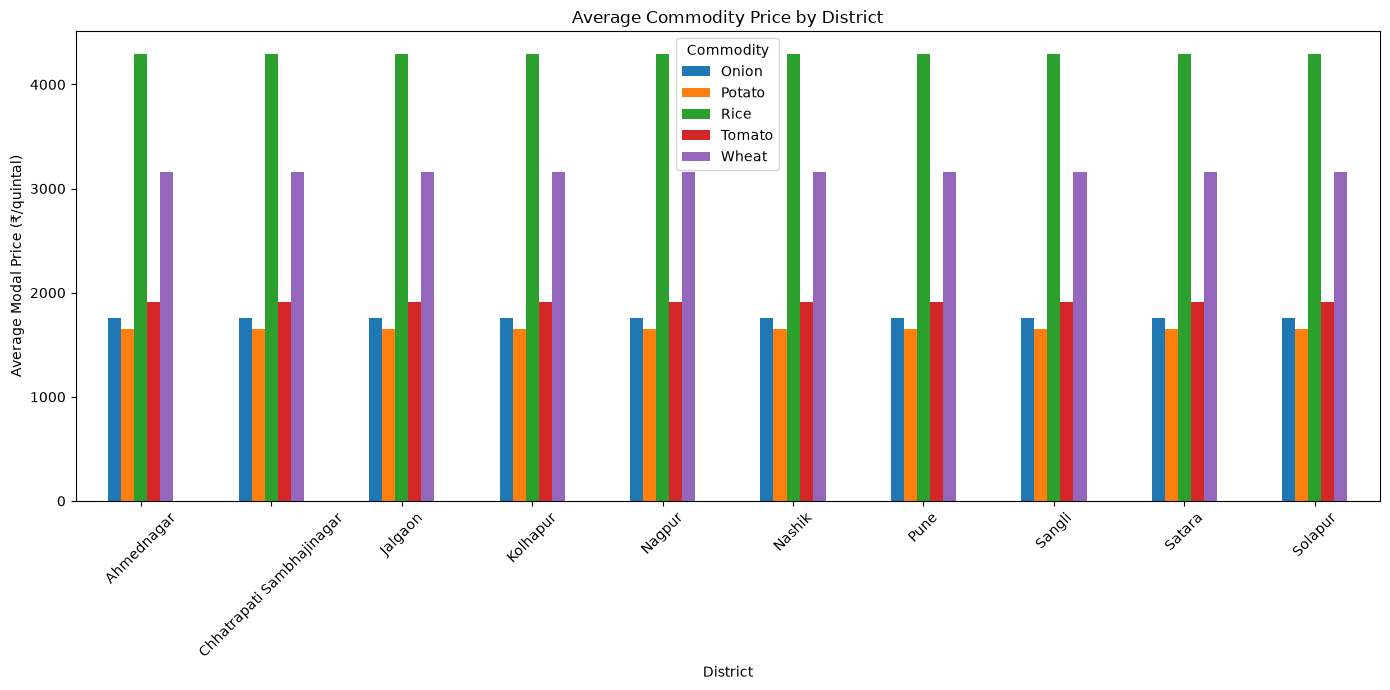


STAKEHOLDER INSIGHT — ANALYSIS 16
Onion: Ahmednagar had the highest average price (₹1754.77/quintal), while Ahmednagar had the lowest (₹1754.77/quintal). The historical gap was 0.00%.
Potato: Ahmednagar had the highest average price (₹1655.97/quintal), while Ahmednagar had the lowest (₹1655.97/quintal). The historical gap was 0.00%.
Rice: Ahmednagar had the highest average price (₹4295.54/quintal), while Ahmednagar had the lowest (₹4295.54/quintal). The historical gap was 0.00%.
Tomato: Ahmednagar had the highest average price (₹1910.62/quintal), while Ahmednagar had the lowest (₹1910.62/quintal). The historical gap was 0.00%.
Wheat: Ahmednagar had the highest average price (₹3157.24/quintal), while Ahmednagar had the lowest (₹3157.24/quintal). The historical gap was 0.00%.

Important: District-level price differences show historical association. They do not prove that location alone causes higher or lower prices.


In [23]:
# ============================================================
# ANALYSIS 16 — DISTRICT-WISE PRICE COMPARISON
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Use existing df
data = df[["Commodity", "District", "Modal_Price"]].copy()

# Convert price to numeric
data["Modal_Price"] = pd.to_numeric(
    data["Modal_Price"],
    errors="coerce"
)

# Remove missing values
data = data.dropna(
    subset=["Commodity", "District", "Modal_Price"]
)

print("=" * 70)
print("DISTRICT-WISE PRICE ANALYSIS")
print("=" * 70)

print("Dataset shape:", data.shape)
print("Number of districts:", data["District"].nunique())

# ------------------------------------------------------------
# Average price by Commodity and District
# ------------------------------------------------------------

district_prices = (
    data.groupby(["Commodity", "District"])["Modal_Price"]
    .mean()
    .reset_index()
)

district_prices = district_prices.rename(
    columns={"Modal_Price": "Average_Price"}
)

print("\nAverage price by Commodity and District:")
print(
    district_prices
    .round(2)
    .to_string(index=False)
)

# ------------------------------------------------------------
# Highest and Lowest district for each crop
# ------------------------------------------------------------

results = []

for commodity in district_prices["Commodity"].unique():

    temp = district_prices[
        district_prices["Commodity"] == commodity
    ].copy()

    highest = temp.loc[
        temp["Average_Price"].idxmax()
    ]

    lowest = temp.loc[
        temp["Average_Price"].idxmin()
    ]

    results.append({
        "Commodity": commodity,
        "Highest_Price_District": highest["District"],
        "Highest_Average_Price": highest["Average_Price"],
        "Lowest_Price_District": lowest["District"],
        "Lowest_Average_Price": lowest["Average_Price"],
        "Price_Gap": (
            highest["Average_Price"]
            - lowest["Average_Price"]
        )
    })

result = pd.DataFrame(results)

# ------------------------------------------------------------
# Percentage gap
# ------------------------------------------------------------

result["Price_Gap_Percent"] = (
    result["Price_Gap"]
    / result["Lowest_Average_Price"]
) * 100

# ------------------------------------------------------------
# Display final result
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("HIGHEST AND LOWEST PRICE DISTRICT BY CROP")
print("=" * 70)

print(
    result.round(2).to_string(index=False)
)

# ------------------------------------------------------------
# Overall strongest district difference
# ------------------------------------------------------------

strongest = result.loc[
    result["Price_Gap_Percent"].idxmax()
]

print("\n" + "=" * 70)
print("LARGEST DISTRICT PRICE GAP")
print("=" * 70)

print("Commodity:", strongest["Commodity"])
print(
    "Highest Price District:",
    strongest["Highest_Price_District"]
)
print(
    "Highest Average Price: ₹",
    round(strongest["Highest_Average_Price"], 2)
)
print(
    "Lowest Price District:",
    strongest["Lowest_Price_District"]
)
print(
    "Lowest Average Price: ₹",
    round(strongest["Lowest_Average_Price"], 2)
)
print(
    "Price Gap: ₹",
    round(strongest["Price_Gap"], 2)
)
print(
    "Price Gap (%):",
    round(strongest["Price_Gap_Percent"], 2),
    "%"
)

# ------------------------------------------------------------
# Graph
# ------------------------------------------------------------

pivot = district_prices.pivot(
    index="District",
    columns="Commodity",
    values="Average_Price"
)

pivot.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Average Commodity Price by District")
plt.xlabel("District")
plt.ylabel("Average Modal Price (₹/quintal)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Stakeholder Insight
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAKEHOLDER INSIGHT — ANALYSIS 16")
print("=" * 70)

for _, row in result.iterrows():

    print(
        f'{row["Commodity"]}: '
        f'{row["Highest_Price_District"]} had the highest '
        f'average price (₹{row["Highest_Average_Price"]:.2f}/quintal), '
        f'while {row["Lowest_Price_District"]} had the lowest '
        f'(₹{row["Lowest_Average_Price"]:.2f}/quintal). '
        f'The historical gap was '
        f'{row["Price_Gap_Percent"]:.2f}%.'
    )

print(
    "\nImportant: District-level price differences show historical "
    "association. They do not prove that location alone causes "
    "higher or lower prices."
)

Analysis 17 — Year-wise Price Trend

We will answer:

“How did the average price of each commodity change from 2023 to 2025?”

YEAR-WISE PRICE ANALYSIS
Dataset shape: (54340, 4)
Years: [np.int32(2023), np.int32(2024), np.int32(2025)]

AVERAGE PRICE BY COMMODITY AND YEAR
Commodity  Year  Average_Price
    Onion  2023        1519.03
    Onion  2024        2363.24
    Onion  2025        1387.41
   Potato  2023        1294.35
   Potato  2024        2179.28
   Potato  2025        1499.04
     Rice  2023        3961.16
     Rice  2024        4329.18
     Rice  2025        4593.35
   Tomato  2023        1979.33
   Tomato  2024        2092.55
   Tomato  2025        1660.97
    Wheat  2023        3137.72
    Wheat  2024        2995.09
    Wheat  2025        3338.47

YEARLY PRICE TABLE
Year          2023     2024     2025
Commodity                           
Onion      1519.03  2363.24  1387.41
Potato     1294.35  2179.28  1499.04
Rice       3961.16  4329.18  4593.35
Tomato     1979.33  2092.55  1660.97
Wheat      3137.72  2995.09  3338.47

2023 TO 2025 PRICE CHANGE
Year          2023     2024     2025  Absolute_Change 

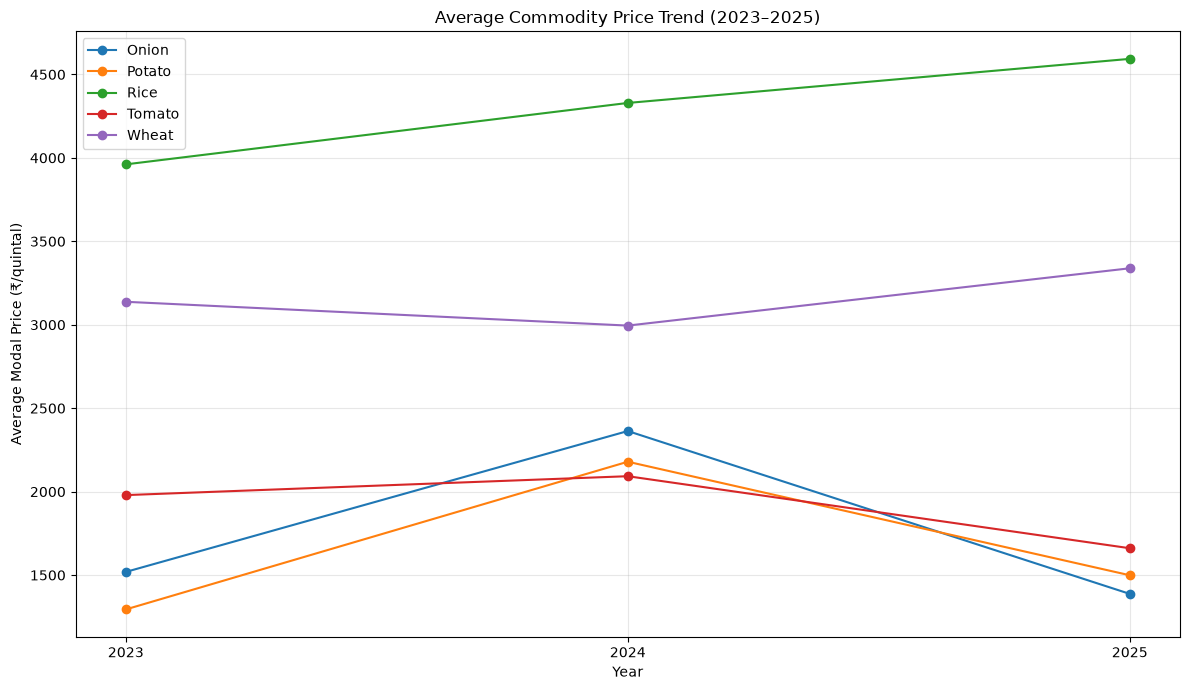


STAKEHOLDER INSIGHT — ANALYSIS 17
Onion: Average price decreased from ₹1519.03 in 2023 to ₹1387.41 in 2025 (-8.67%).
Potato: Average price increased from ₹1294.35 in 2023 to ₹1499.04 in 2025 (15.81%).
Rice: Average price increased from ₹3961.16 in 2023 to ₹4593.35 in 2025 (15.96%).
Tomato: Average price decreased from ₹1979.33 in 2023 to ₹1660.97 in 2025 (-16.08%).
Wheat: Average price increased from ₹3137.72 in 2023 to ₹3338.47 in 2025 (6.40%).

Important: Year-wise price changes show historical trends and do not prove that a particular factor caused the change.


In [24]:
# ============================================================
# ANALYSIS 17 — YEAR-WISE PRICE TREND
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Use existing dataframe
data = df[["Date", "Commodity", "Modal_Price"]].copy()

# Convert columns
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data["Modal_Price"] = pd.to_numeric(
    data["Modal_Price"],
    errors="coerce"
)

# Create Year
data["Year"] = data["Date"].dt.year

# Remove missing values
data = data.dropna(
    subset=["Year", "Commodity", "Modal_Price"]
)

print("=" * 70)
print("YEAR-WISE PRICE ANALYSIS")
print("=" * 70)

print("Dataset shape:", data.shape)
print("Years:", sorted(data["Year"].unique()))

# ------------------------------------------------------------
# Average price by Commodity and Year
# ------------------------------------------------------------

yearly_prices = (
    data.groupby(["Commodity", "Year"])["Modal_Price"]
    .mean()
    .reset_index()
)

yearly_prices = yearly_prices.rename(
    columns={"Modal_Price": "Average_Price"}
)

print("\n" + "=" * 70)
print("AVERAGE PRICE BY COMMODITY AND YEAR")
print("=" * 70)

print(
    yearly_prices.round(2).to_string(index=False)
)

# ------------------------------------------------------------
# Pivot table
# ------------------------------------------------------------

year_table = yearly_prices.pivot(
    index="Commodity",
    columns="Year",
    values="Average_Price"
)

print("\n" + "=" * 70)
print("YEARLY PRICE TABLE")
print("=" * 70)

print(
    year_table.round(2).to_string()
)

# ------------------------------------------------------------
# Calculate 2023 → 2025 change
# ------------------------------------------------------------

result = year_table.copy()

result["Absolute_Change"] = (
    result[2025] - result[2023]
)

result["Percentage_Change"] = (
    result["Absolute_Change"]
    / result[2023]
) * 100

print("\n" + "=" * 70)
print("2023 TO 2025 PRICE CHANGE")
print("=" * 70)

print(
    result.round(2).to_string()
)

# ------------------------------------------------------------
# Highest increase
# ------------------------------------------------------------

highest_increase = result.loc[
    result["Percentage_Change"].idxmax()
]

# ------------------------------------------------------------
# Highest decrease
# ------------------------------------------------------------

highest_decrease = result.loc[
    result["Percentage_Change"].idxmin()
]

print("\n" + "=" * 70)
print("STRONGEST PRICE INCREASE")
print("=" * 70)

print("Commodity:", highest_increase.name)
print("2023 Average Price: ₹",
      round(highest_increase[2023], 2))
print("2025 Average Price: ₹",
      round(highest_increase[2025], 2))
print("Change: ₹",
      round(highest_increase["Absolute_Change"], 2))
print("Change (%):",
      round(highest_increase["Percentage_Change"], 2),
      "%")

print("\n" + "=" * 70)
print("STRONGEST PRICE DECREASE")
print("=" * 70)

print("Commodity:", highest_decrease.name)
print("2023 Average Price: ₹",
      round(highest_decrease[2023], 2))
print("2025 Average Price: ₹",
      round(highest_decrease[2025], 2))
print("Change: ₹",
      round(highest_decrease["Absolute_Change"], 2))
print("Change (%):",
      round(highest_decrease["Percentage_Change"], 2),
      "%")

# ------------------------------------------------------------
# Line chart
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

for commodity in yearly_prices["Commodity"].unique():

    temp = yearly_prices[
        yearly_prices["Commodity"] == commodity
    ]

    plt.plot(
        temp["Year"],
        temp["Average_Price"],
        marker="o",
        label=commodity
    )

plt.title("Average Commodity Price Trend (2023–2025)")
plt.xlabel("Year")
plt.ylabel("Average Modal Price (₹/quintal)")
plt.xticks([2023, 2024, 2025])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Stakeholder Insight
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAKEHOLDER INSIGHT — ANALYSIS 17")
print("=" * 70)

for commodity, row in result.iterrows():

    direction = (
        "increased"
        if row["Absolute_Change"] > 0
        else "decreased"
        if row["Absolute_Change"] < 0
        else "remained stable"
    )

    print(
        f"{commodity}: Average price {direction} "
        f"from ₹{row[2023]:.2f} in 2023 "
        f"to ₹{row[2025]:.2f} in 2025 "
        f"({row['Percentage_Change']:.2f}%)."
    )

print(
    "\nImportant: Year-wise price changes show historical trends "
    "and do not prove that a particular factor caused the change."
)

Analysis 19 — Arrival Trend by Year

Question we will answer:

“How did market arrivals change from 2023 to 2025 for each commodity?”

Checking required columns...
Commodity -> True
Year -> True
Arrival -> True

YEAR-WISE AVERAGE MARKET ARRIVAL
Commodity  Year      Arrival
    Onion  2023 24186.528650
    Onion  2024 18290.238670
    Onion  2025 20539.346274
   Potato  2023  2183.815427
   Potato  2024  2161.353611
   Potato  2025  2317.254670
     Rice  2023   375.363889
     Rice  2024   209.622191
     Rice  2025   348.001099
   Tomato  2023  2110.774904
   Tomato  2024  2048.106399
   Tomato  2025  2172.606336
    Wheat  2023  1434.583929
    Wheat  2024   800.031680
    Wheat  2025  1346.641099

AVERAGE ARRIVAL BY COMMODITY AND YEAR
Year           2023      2024      2025
Commodity                              
Onion      24186.53  18290.24  20539.35
Potato      2183.82   2161.35   2317.25
Rice         375.36    209.62    348.00
Tomato      2110.77   2048.11   2172.61
Wheat       1434.58    800.03   1346.64

ARRIVAL CHANGE: 2023 VS 2025
Commodity  Arrival_2023  Arrival_2025   Change  Change_Percent
    Onion     

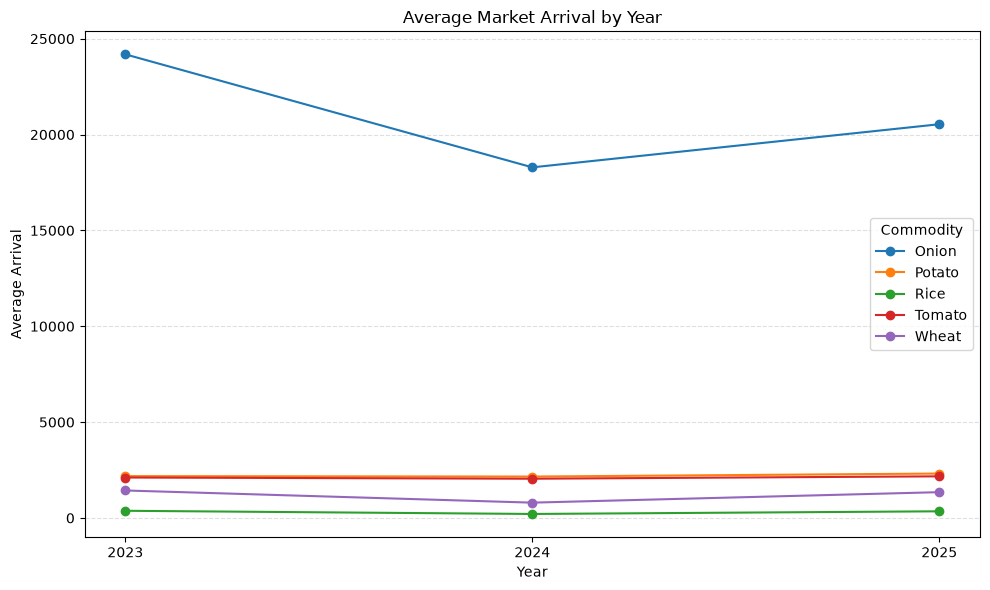


STAKEHOLDER INSIGHT — ANALYSIS 19
Onion: Average market arrival decreased from 24186.53 in 2023 to 20539.35 in 2025 (-15.08%).
Potato: Average market arrival increased from 2183.82 in 2023 to 2317.25 in 2025 (6.11%).
Rice: Average market arrival decreased from 375.36 in 2023 to 348.00 in 2025 (-7.29%).
Tomato: Average market arrival increased from 2110.77 in 2023 to 2172.61 in 2025 (2.93%).
Wheat: Average market arrival decreased from 1434.58 in 2023 to 1346.64 in 2025 (-6.13%).

Important: Arrival trends show historical changes in market supply.
They do not prove that changes in arrival directly caused price changes.


In [26]:


# Convert required columns
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Arrival"] = pd.to_numeric(df["Arrival"], errors="coerce")

# Create Year
df["Year"] = df["Date"].dt.year

# Check required columns
required = ["Commodity", "Year", "Arrival"]

print("Checking required columns...")
for col in required:
    print(col, "->", col in df.columns)

# Remove missing values
data = df.dropna(subset=["Commodity", "Year", "Arrival"]).copy()

# Average arrival by commodity and year
yearly_arrival = (
    data.groupby(["Commodity", "Year"])["Arrival"]
    .mean()
    .reset_index()
)

print("\n" + "="*70)
print("YEAR-WISE AVERAGE MARKET ARRIVAL")
print("="*70)

print(yearly_arrival.to_string(index=False))

# Pivot table
pivot = yearly_arrival.pivot(
    index="Commodity",
    columns="Year",
    values="Arrival"
)

print("\n" + "="*70)
print("AVERAGE ARRIVAL BY COMMODITY AND YEAR")
print("="*70)

print(pivot.round(2))

# ---------------------------------------------------------
# 2023 vs 2025 change
# ---------------------------------------------------------

results = []

for commodity in pivot.index:

    if 2023 in pivot.columns and 2025 in pivot.columns:

        arrival_2023 = pivot.loc[commodity, 2023]
        arrival_2025 = pivot.loc[commodity, 2025]

        change = arrival_2025 - arrival_2023

        if arrival_2023 != 0:
            change_percent = (change / arrival_2023) * 100
        else:
            change_percent = 0

        results.append({
            "Commodity": commodity,
            "Arrival_2023": arrival_2023,
            "Arrival_2025": arrival_2025,
            "Change": change,
            "Change_Percent": change_percent
        })

arrival_change = pd.DataFrame(results)

print("\n" + "="*70)
print("ARRIVAL CHANGE: 2023 VS 2025")
print("="*70)

print(arrival_change.round(2).to_string(index=False))

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

for commodity in pivot.index:
    plt.plot(
        pivot.columns,
        pivot.loc[commodity],
        marker="o",
        label=commodity
    )

plt.title("Average Market Arrival by Year")
plt.xlabel("Year")
plt.ylabel("Average Arrival")
plt.xticks([2023, 2024, 2025])
plt.legend(title="Commodity")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Stakeholder insight
# ---------------------------------------------------------

print("\n" + "="*70)
print("STAKEHOLDER INSIGHT — ANALYSIS 19")
print("="*70)

for _, row in arrival_change.iterrows():

    direction = "increased" if row["Change"] > 0 else "decreased"

    print(
        f'{row["Commodity"]}: Average market arrival {direction} '
        f'from {row["Arrival_2023"]:.2f} in 2023 to '
        f'{row["Arrival_2025"]:.2f} in 2025 '
        f'({row["Change_Percent"]:.2f}%).'
    )

print("\nImportant: Arrival trends show historical changes in market supply.")
print("They do not prove that changes in arrival directly caused price changes.")

Analysis 20 — Price Trend / Momentum Analysis

Which crop has the strongest upward or downward price momentum over the 3-year period?

In [28]:
import pandas as pd
import numpy as np

# ============================================================
# ANALYSIS 20 — PRICE MOMENTUM / LONG-TERM PRICE TREND
# ============================================================

print("=" * 70)
print("ANALYSIS 20 — PRICE MOMENTUM / LONG-TERM PRICE TREND")
print("=" * 70)

# ------------------------------------------------------------
# 2. CHECK REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = ["Date", "Commodity", "Modal_Price"]

print("\nChecking required columns...")

for col in required_columns:
    print(f"{col} -> {col in df.columns}")

# ------------------------------------------------------------
# 3. CLEAN DATA
# ------------------------------------------------------------

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Modal_Price"] = pd.to_numeric(
    df["Modal_Price"],
    errors="coerce"
)

df = df.dropna(
    subset=["Date", "Commodity", "Modal_Price"]
)

# ------------------------------------------------------------
# 4. CREATE YEAR-MONTH
# ------------------------------------------------------------

df["YearMonth"] = df["Date"].dt.to_period("M")

# Monthly average price
monthly_price = (
    df.groupby(["Commodity", "YearMonth"])["Modal_Price"]
    .mean()
    .reset_index()
)

# ------------------------------------------------------------
# 5. FIRST 3 MONTHS AND LAST 3 MONTHS
# ------------------------------------------------------------

results = []

for commodity in monthly_price["Commodity"].unique():

    temp = monthly_price[
        monthly_price["Commodity"] == commodity
    ].sort_values("YearMonth")

    # First 3 months
    first_3 = temp.head(3)["Modal_Price"].mean()

    # Last 3 months
    last_3 = temp.tail(3)["Modal_Price"].mean()

    change = last_3 - first_3

    if first_3 != 0:
        change_percent = (change / first_3) * 100
    else:
        change_percent = np.nan

    if change_percent > 5:
        trend = "Strong Upward"
    elif change_percent > 0:
        trend = "Upward"
    elif change_percent < -5:
        trend = "Strong Downward"
    elif change_percent < 0:
        trend = "Downward"
    else:
        trend = "Stable"

    results.append({
        "Commodity": commodity,
        "First_3_Month_Avg": first_3,
        "Last_3_Month_Avg": last_3,
        "Price_Change": change,
        "Change_Percent": change_percent,
        "Trend": trend
    })

trend_df = pd.DataFrame(results)

# ------------------------------------------------------------
# 6. DISPLAY RESULT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PRICE MOMENTUM RESULT")
print("=" * 70)

print(
    trend_df.round(2).to_string(index=False)
)

# ------------------------------------------------------------
# 7. STRONGEST UPWARD / DOWNWARD TREND
# ------------------------------------------------------------

strongest_upward = trend_df.loc[
    trend_df["Change_Percent"].idxmax()
]

strongest_downward = trend_df.loc[
    trend_df["Change_Percent"].idxmin()
]

print("\n" + "=" * 70)
print("STRONGEST PRICE MOMENTUM")
print("=" * 70)

print(
    f"Strongest upward trend: "
    f"{strongest_upward['Commodity']} "
    f"({strongest_upward['Change_Percent']:.2f}%)"
)

print(
    f"Strongest downward trend: "
    f"{strongest_downward['Commodity']} "
    f"({strongest_downward['Change_Percent']:.2f}%)"
)

# ------------------------------------------------------------
# 8. STAKEHOLDER INSIGHT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAKEHOLDER INSIGHT — ANALYSIS 20")
print("=" * 70)

for _, row in trend_df.iterrows():

    print(
        f"{row['Commodity']}: "
        f"price changed from ₹{row['First_3_Month_Avg']:.2f} "
        f"to ₹{row['Last_3_Month_Avg']:.2f} "
        f"({row['Change_Percent']:.2f}%). "
        f"Trend = {row['Trend']}."
    )

print("\nImportant: This analysis identifies historical price momentum.")
print("It does not prove that the observed trend will continue in the future.")

ANALYSIS 20 — PRICE MOMENTUM / LONG-TERM PRICE TREND

Checking required columns...
Date -> True
Commodity -> True
Modal_Price -> True

PRICE MOMENTUM RESULT
Commodity  First_3_Month_Avg  Last_3_Month_Avg  Price_Change  Change_Percent         Trend
    Onion             943.73           1285.53        341.80           36.22 Strong Upward
   Potato            1250.85           1452.25        201.41           16.10 Strong Upward
     Rice            3879.67           4874.34        994.67           25.64 Strong Upward
   Tomato            1035.88           2189.68       1153.80          111.38 Strong Upward
    Wheat            3072.76           3361.76        289.01            9.41 Strong Upward

STRONGEST PRICE MOMENTUM
Strongest upward trend: Tomato (111.38%)
Strongest downward trend: Wheat (9.41%)

STAKEHOLDER INSIGHT — ANALYSIS 20
Onion: price changed from ₹943.73 to ₹1285.53 (36.22%). Trend = Strong Upward.
Potato: price changed from ₹1250.85 to ₹1452.25 (16.10%). Trend = Strong Upw

# ============================================================
# ANALYSIS 21 — PRICE SHOCK / CRISIS EVENTS
# ============================================================

In [31]:
import pandas as pd
import numpy as np

print("=" * 70)
print("ANALYSIS 21 — PRICE SHOCK / CRISIS EVENTS")
print("=" * 70)


df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Modal_Price"] = pd.to_numeric(df["Modal_Price"], errors="coerce")

# ------------------------------------------------------------
# 2. Check required columns
# ------------------------------------------------------------

required_columns = [
    "Date",
    "Commodity",
    "Modal_Price"
]

print("\nChecking required columns...")

for col in required_columns:
    print(col, "->", col in df.columns)

# ------------------------------------------------------------
# 3. Clean data
# ------------------------------------------------------------

df = df.dropna(
    subset=["Date", "Commodity", "Modal_Price"]
).copy()

df = df.sort_values(
    ["Commodity", "Date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 4. Calculate daily price change
# ------------------------------------------------------------

df["Daily_Price_Change"] = (
    df.groupby("Commodity")["Modal_Price"]
    .pct_change() * 100
)

# ------------------------------------------------------------
# 5. Define price shock
# ------------------------------------------------------------
# A price movement greater than +/- 20% in one observation
# is treated as an abnormal price shock.

SHOCK_THRESHOLD = 20

df["Price_Shock"] = (
    df["Daily_Price_Change"].abs() >= SHOCK_THRESHOLD
)

# ------------------------------------------------------------
# 6. Count shocks by commodity
# ------------------------------------------------------------

shock_summary = (
    df.groupby("Commodity")
    .agg(
        Total_Observations=("Modal_Price", "count"),
        Shock_Events=("Price_Shock", "sum")
    )
    .reset_index()
)

shock_summary["Shock_Percentage"] = (
    shock_summary["Shock_Events"]
    / shock_summary["Total_Observations"]
    * 100
)

shock_summary = shock_summary.sort_values(
    "Shock_Events",
    ascending=False
)

print("\n" + "=" * 70)
print("PRICE SHOCK SUMMARY")
print("=" * 70)

print(shock_summary.to_string(index=False))

# ------------------------------------------------------------
# 7. Find strongest individual price shocks
# ------------------------------------------------------------

shock_events = df[
    df["Price_Shock"] == True
].copy()

shock_events["Shock_Type"] = np.where(
    shock_events["Daily_Price_Change"] > 0,
    "Price Spike",
    "Price Crash"
)

shock_events = shock_events.sort_values(
    "Daily_Price_Change"
)

print("\n" + "=" * 70)
print("TOP PRICE CRASHES")
print("=" * 70)

print(
    shock_events[
        ["Date", "Commodity",
         "Modal_Price",
         "Daily_Price_Change",
         "Shock_Type"]
    ]
    .head(10)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("TOP PRICE SPIKES")
print("=" * 70)

print(
    shock_events[
        ["Date", "Commodity",
         "Modal_Price",
         "Daily_Price_Change",
         "Shock_Type"]
    ]
    .tail(10)
    .sort_values(
        "Daily_Price_Change",
        ascending=False
    )
    .to_string(index=False)
)

# ------------------------------------------------------------
# 8. Find crop with most crisis events
# ------------------------------------------------------------

top_crop = shock_summary.iloc[0]

print("\n" + "=" * 70)
print("PRICE SHOCK RESULT")
print("=" * 70)

print(
    f"Crop with most price shock events: "
    f"{top_crop['Commodity']}"
)

print(
    f"Number of shock events: "
    f"{int(top_crop['Shock_Events'])}"
)

print(
    f"Shock frequency: "
    f"{top_crop['Shock_Percentage']:.2f}%"
)

# ------------------------------------------------------------
# 9. Stakeholder Insight
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAKEHOLDER INSIGHT — ANALYSIS 21")
print("=" * 70)

for _, row in shock_summary.iterrows():

    print(
        f"{row['Commodity']}: "
        f"{int(row['Shock_Events'])} abnormal price movements "
        f"out of {int(row['Total_Observations'])} observations "
        f"({row['Shock_Percentage']:.2f}%)."
    )

print(
    f"\n{top_crop['Commodity']} experienced the highest number "
    f"of abnormal price movements in the dataset."
)

print(
    "\nImportant: The 20% threshold is a project-defined "
    "criterion for identifying abnormal price movements. "
    "Price shocks do not automatically indicate a specific cause."
)

ANALYSIS 21 — PRICE SHOCK / CRISIS EVENTS

Checking required columns...
Date -> True
Commodity -> True
Modal_Price -> True

PRICE SHOCK SUMMARY
Commodity  Total_Observations  Shock_Events  Shock_Percentage
    Wheat               10910           177          1.622365
   Tomato               10870           163          1.499540
     Rice               10800           134          1.240741
   Potato               10870            37          0.340386
    Onion               10890            31          0.284665

TOP PRICE CRASHES
      Date Commodity  Modal_Price  Daily_Price_Change  Shock_Type
2024-02-19    Potato      1505.99          -86.166152 Price Crash
2024-06-23      Rice      1200.00          -75.335692 Price Crash
2024-04-21      Rice      1200.00          -74.170385 Price Crash
2024-05-19      Rice      1200.00          -73.199929 Price Crash
2024-06-16      Rice      1200.00          -71.522547 Price Crash
2024-12-12    Tomato       666.00          -70.885373 Price Crash
202

# ANALYSIS 22 — OVERALL FARMER RISK RANKING

In [34]:


import pandas as pd
import numpy as np

print("=" * 70)
print("ANALYSIS 22 — OVERALL FARMER RISK RANKING")
print("=" * 70)


df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Modal_Price"] = pd.to_numeric(df["Modal_Price"], errors="coerce")

df = df.dropna(subset=["Commodity", "Modal_Price"])

print("\nDataset shape:", df.shape)
print("Commodities:", df["Commodity"].unique())


# ==============================================================
# 1. PRICE VOLATILITY
# ==============================================================

volatility = (
    df.groupby("Commodity")["Modal_Price"]
    .agg(["mean", "std"])
    .reset_index()
)

volatility["CV_Percent"] = (
    volatility["std"] / volatility["mean"] * 100
)

volatility = volatility[
    ["Commodity", "CV_Percent"]
]


# ==============================================================
# 2. BELOW-COST MONTHS
# ==============================================================

# Project assumptions from Analysis 8
costs = {
    "Onion": 1400,
    "Potato": 1300,
    "Rice": 2500,
    "Tomato": 1600,
    "Wheat": 2000
}

monthly = (
    df.assign(YearMonth=df["Date"].dt.to_period("M"))
      .groupby(["Commodity", "YearMonth"])["Modal_Price"]
      .mean()
      .reset_index()
)

monthly["Cost_of_Cultivation"] = (
    monthly["Commodity"].map(costs)
)

monthly["Below_Cost"] = (
    monthly["Modal_Price"] <
    monthly["Cost_of_Cultivation"]
)

below_cost = (
    monthly.groupby("Commodity")["Below_Cost"]
    .mean()
    .reset_index()
)

below_cost["Below_Cost_Percent"] = (
    below_cost["Below_Cost"] * 100
)

below_cost = below_cost[
    ["Commodity", "Below_Cost_Percent"]
]


# ==============================================================
# 3. PRICE SHOCK FREQUENCY
# ==============================================================

df = df.sort_values(["Commodity", "Date"])

df["Daily_Price_Change"] = (
    df.groupby("Commodity")["Modal_Price"]
      .pct_change() * 100
)

df["Price_Shock"] = (
    df["Daily_Price_Change"].abs() >= 20
)

shock = (
    df.groupby("Commodity")["Price_Shock"]
      .mean()
      .reset_index()
)

shock["Shock_Percent"] = (
    shock["Price_Shock"] * 100
)

shock = shock[
    ["Commodity", "Shock_Percent"]
]


# ==============================================================
# 4. LONG-TERM PRICE MOMENTUM
# ==============================================================

df["Year"] = df["Date"].dt.year

yearly = (
    df.groupby(["Commodity", "Year"])["Modal_Price"]
      .mean()
      .reset_index()
)

first_year = (
    yearly[yearly["Year"] == yearly["Year"].min()]
    [["Commodity", "Modal_Price"]]
    .rename(columns={"Modal_Price": "First_Year_Price"})
)

last_year = (
    yearly[yearly["Year"] == yearly["Year"].max()]
    [["Commodity", "Modal_Price"]]
    .rename(columns={"Modal_Price": "Last_Year_Price"})
)

momentum = first_year.merge(
    last_year,
    on="Commodity"
)

momentum["Price_Change_Percent"] = (
    (momentum["Last_Year_Price"]
     - momentum["First_Year_Price"])
    / momentum["First_Year_Price"] * 100
)

momentum = momentum[
    ["Commodity", "Price_Change_Percent"]
]


# ==============================================================
# 5. MERGE ALL RISK INDICATORS
# ==============================================================

risk = volatility.merge(
    below_cost,
    on="Commodity"
)

risk = risk.merge(
    shock,
    on="Commodity"
)

risk = risk.merge(
    momentum,
    on="Commodity"
)


# ==============================================================
# 6. NORMALIZE RISK VARIABLES
# ==============================================================

def min_max_score(series):
    if series.max() == series.min():
        return pd.Series([50] * len(series), index=series.index)

    return (
        (series - series.min())
        / (series.max() - series.min())
        * 100
    )


# Higher volatility = higher risk
risk["Volatility_Risk"] = min_max_score(
    risk["CV_Percent"]
)

# More below-cost months = higher risk
risk["Below_Cost_Risk"] = min_max_score(
    risk["Below_Cost_Percent"]
)

# More shocks = higher risk
risk["Shock_Risk"] = min_max_score(
    risk["Shock_Percent"]
)

# Negative long-term momentum = higher risk
# Convert momentum so lower/negative growth gets higher risk.

risk["Momentum_Risk"] = min_max_score(
    -risk["Price_Change_Percent"]
)


# ==============================================================
# 7. FINAL RISK SCORE
# ==============================================================

risk["Farmer_Risk_Score"] = (
    risk["Volatility_Risk"] * 0.30
    + risk["Below_Cost_Risk"] * 0.30
    + risk["Shock_Risk"] * 0.20
    + risk["Momentum_Risk"] * 0.20
)


# ==============================================================
# 8. RISK CATEGORY
# ==============================================================

def risk_category(score):

    if score >= 66:
        return "High Risk"

    elif score >= 33:
        return "Medium Risk"

    else:
        return "Low Risk"


risk["Risk_Level"] = (
    risk["Farmer_Risk_Score"]
    .apply(risk_category)
)


# ==============================================================
# 9. FINAL RESULT
# ==============================================================

risk = risk.sort_values(
    "Farmer_Risk_Score",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("OVERALL FARMER RISK RANKING")
print("=" * 70)

print(
    risk[
        [
            "Commodity",
            "CV_Percent",
            "Below_Cost_Percent",
            "Shock_Percent",
            "Price_Change_Percent",
            "Farmer_Risk_Score",
            "Risk_Level"
        ]
    ].round(2)
)


# ==============================================================
# 10. HIGHEST AND LOWEST RISK
# ==============================================================

highest = risk.iloc[0]
lowest = risk.iloc[-1]

print("\n" + "=" * 70)
print("HIGHEST FARMER RISK")
print("=" * 70)

print("Commodity:", highest["Commodity"])
print("Risk Score:", round(highest["Farmer_Risk_Score"], 2))
print("Risk Level:", highest["Risk_Level"])


print("\n" + "=" * 70)
print("LOWEST FARMER RISK")
print("=" * 70)

print("Commodity:", lowest["Commodity"])
print("Risk Score:", round(lowest["Farmer_Risk_Score"], 2))
print("Risk Level:", lowest["Risk_Level"])


# ==============================================================
# 11. STAKEHOLDER INSIGHT
# ==============================================================

print("\n" + "=" * 70)
print("STAKEHOLDER INSIGHT — ANALYSIS 22")
print("=" * 70)

for _, row in risk.iterrows():

    print(
        f"{row['Commodity']}: "
        f"Farmer Risk Score = {row['Farmer_Risk_Score']:.2f}, "
        f"Risk Level = {row['Risk_Level']}."
    )

print("\nInsight:")
print(
    f"{highest['Commodity']} has the highest overall farmer risk "
    f"under the project's risk scoring framework."
)

print(
    f"{lowest['Commodity']} has the lowest overall farmer risk "
    f"under the project's risk scoring framework."
)

print("\nImportant:")
print(
    "The Farmer Risk Score is a project-defined composite indicator. "
    "It is not an official government risk classification."
)

ANALYSIS 22 — OVERALL FARMER RISK RANKING

Dataset shape: (54340, 31)
Commodities: <ArrowStringArray>
['Onion', 'Potato', 'Rice', 'Tomato', 'Wheat']
Length: 5, dtype: str

OVERALL FARMER RISK RANKING
  Commodity  CV_Percent  Below_Cost_Percent  Shock_Percent  \
0    Tomato       76.19               50.00           1.50   
1     Onion       52.67               50.00           0.28   
2     Wheat       13.83                0.00           1.62   
3    Potato       34.22               16.67           0.34   
4      Rice       15.12                0.00           1.24   

   Price_Change_Percent  Farmer_Risk_Score   Risk_Level  
0                -16.08              98.16    High Risk  
1                 -8.67              64.06  Medium Risk  
2                  6.40              25.97     Low Risk  
3                 15.81              20.73     Low Risk  
4                 15.96              14.91     Low Risk  

HIGHEST FARMER RISK
Commodity: Tomato
Risk Score: 98.16
Risk Level: High Risk
